# Prepare

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from copy import deepcopy

import experiments as meas
from slab import AttrDict
from experiments import MultimodeStation, CharacterizationRunner

from job_server import JobClient
from job_server.database import get_database
from job_server.config_versioning import ConfigVersionManager

# Initialize database and config manager
db = get_database()
config_dir = 'D:/python/multimode_expts/configs'
config_manager = ConfigVersionManager(config_dir)

# Initialize job client (handle submitting and waiting for jobs)
client = JobClient()

# Check server health
health = client.health_check()
print(f"Server status: {health['status']}")
print(f"Pending jobs: {health['pending_jobs']}")

Importing all classes from  D:\python\multimode_expts\experiments\dual_rail
Importing all classes from  D:\python\multimode_expts\experiments\qsim
Importing all classes from  D:\python\multimode_expts\experiments\qubit_cavity
Importing all classes from  D:\python\multimode_expts\experiments\single_qubit
Skipped top-level files ['characterization_runner.py', 'dataset.py', 'MM_base.py', 'MM_dual_rail_base.py', 'MM_rb_base.py', 'mock_hardware.py', 'sequential_experiment.py', 'sequential_experiment_classes.py', 'station.py', 'sweep_runner.py']
Server status: healthy
Pending jobs: 0


In [2]:
# Initialize database and config manager
db = get_database()
config_dir = 'D:/python/multimode_expts/configs'
config_manager = ConfigVersionManager(config_dir)

# Initialize job client (handle submitting and waiting for jobs)
client = JobClient()

# Check server health
health = client.health_check()
client.print_queue()


=== Job Queue ===

No job currently running

Pending: 0 jobs



In [ ]:
# Who is running these experiments??
user = 'jonginn'

print(f"Welcome {user}!")

Welcome jonginn!


In [ ]:
# Initialize station to retrieve soc and configs
station = MultimodeStation(
    user = user,
    experiment_name = "260511_qsim_darkmode",
    
    hardware_config="CFG-HW-20260520-00044",
    storage_man_file="CFG-M1-20260519-00015",
    floquet_file="CFG-FL-20260520-00001",
    # multiphoton_config="versions/multiphoton_config/CFG-MP-20260115-00001.yml",
)

[STATION] Using hardware_config version: CFG-HW-20260520-00044
[STATION] Using main multiphoton_config version: CFG-MP-20260121-00001
[STATION] Using man1_storage_swap version: CFG-M1-20260519-00015
[STATION] Using floquet_storage_swap version: CFG-FL-20260520-00001
[STATION] vault_root not set in config; lab-notebook logging disabled.
Data, plots, logs will be stored in: D:\experiments\260511_qsim_darkmode
Hardware configs will be read from D:\python\multimode_expts\configs\versions\hardware_config\CFG-HW-20260520-00044.yml
dict_keys(['Pyro.NameServer', 'Qick101'])
QICK running on ZCU216, software version 0.2.291

Firmware configuration (built Tue Oct 15 12:06:51 2024):

	Global clocks (MHz): tProcessor 430.080, RF reference 245.760

	7 signal generator channels:
	0:	axis_signal_gen_v6 - envelope memory 32768 samples (5.128 us)
		fs=6389.760 MHz, fabric=399.360 MHz, 32-bit DDS, range=6389.760 MHz
		DAC tile 2, blk 0 is 0_230, on JHC3
	1:	axis_signal_gen_v6 - envelope memory 32768 samp

In [4]:
from experiments.MM_dual_rail_base import MM_dual_rail_base

def get_floquet_parameters(station, man_mode_no, stor_mode_no):
    """
    Get pulse parameters for a given storage mode. 
    Also returns prepulse and postpulse (single photon prep and meas for ge meas)

    Args:
        station: MultimodeStation object for managing frequency data.
        man_mode_no: Manipulation mode number.
        stor_mode_no: Storage mode number.

    Returns:
        A tuple containing freq, gain, ch, prepulse, and postpulse.
    """
    stor_name = 'M' + str(man_mode_no) + '-S' + str(stor_mode_no)
    freq = station.ds_floquet.get_freq(stor_name)
    gain = station.ds_floquet.get_gain(stor_name)
    length = station.ds_floquet.get_len(stor_name)
    pi_frac = station.ds_floquet.get_pi_frac(stor_name)
    ch = 'low' if freq < 1000 else 'high'

    mm_base_dummy = MM_dual_rail_base(station.hardware_cfg, station.soccfg)
    prep_man_pi = mm_base_dummy.prep_man_photon(man_mode_no)
    prepulse = mm_base_dummy.get_prepulse_creator(prep_man_pi).pulse.tolist()
    postpulse = mm_base_dummy.get_prepulse_creator(prep_man_pi[-1:-3:-1]).pulse.tolist() # for ge meas, only do f0g1 and ef pi

    return freq, gain, length, pi_frac, ch, prepulse, postpulse


## Datset for Sidebands

In [ ]:
station.ds_storage.df

In [ ]:
# Override/initalize using the storage dataset
station.ds_floquet.import_from_swap_dataset(station.ds_storage, gain_div=[2, 1, 1, 1, 2, 4, 1], 
                                    pi_div=[20, 40, 40, 40, 20, 10, 1])
station.snapshot_floquet_storage_swap(update_main=False)

In [ ]:
station.ds_floquet.df

In [ ]:
station.ds_floquet.update_len('M1-S4', 0.1)

# Single shot

In [6]:
# Define defaults, smart config preprocessing and post-measurement updates
# =====================================
singleshot_defaults = AttrDict(dict(    
    reps=5000,
    relax_delay=500,
    check_f=False,
    active_reset=False,
    man_reset=False,
    storage_reset=False,
    qubit=0,
    pulse_manipulate=False,
    # cavity_freq=4984.373226159381,
    # cavity_gain=400,
    # cavity_length=2,
    prepulse=False,
    pre_sweep_pulse=None,
    gate_based=True,
    qubits=[0],
)) # Shouldn't be modifying this on the fly!
# You can use kwargs in the run function to override these values

def singleshot_postproc(station, expt):
    expt.analyze(plot=False, station=station, subdir=station.autocalib_path)
    fids = expt.data['fids']
    confusion_matrix = expt.data['confusion_matrix']
    thresholds_new = expt.data['thresholds']
    angle = expt.data['angle']
    print(fids)

    hardware_cfg = station.hardware_cfg
    hardware_cfg.device.readout.phase = [hardware_cfg.device.readout.phase[0] + angle]
    hardware_cfg.device.readout.threshold = thresholds_new
    hardware_cfg.device.readout.threshold_list = [thresholds_new]
    hardware_cfg.device.readout.Ie = [np.median(expt.data['Ie_rot'])]
    hardware_cfg.device.readout.Ig = [np.median(expt.data['Ig_rot'])]
    if expt.cfg.expt.active_reset:
        hardware_cfg.device.readout.confusion_matrix_with_active_reset = confusion_matrix
    else:
        hardware_cfg.device.readout.confusion_matrix_without_reset = confusion_matrix
    print('Updated readout!')

Job submitted: JOB-20260521-00220 (queue position: 1)

[0.0s] Job JOB-20260521-00220: pending

[40.2s] Job JOB-20260521-00220: running
[WORKER] Loading HistogramExperiment from experiments.single_qubit.single_shot
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260521-00220_HistogramExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.3mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 66%|████████████████████████▏            | 3276/5000 [00:06<00:03, 499.05it/s]
[80.4s] Job JOB-20260521-00220: completed
100%|█████████████████████████████████████| 5000/5000 [00:10<00:00, 499.31it/s]
Unrotated:
Ig -64.34594594594594 +/- 27.979893824474924 	 Qg -83.35 +/- 26.811101652721604 	 Amp g 105.2977837358346
Ie 32.33513513513513 +/- 32.17186321077259 	 Qe -62.58513513513513 +/- 27.660910389654298 	 Amp e 70.44473084688859
Rotated:
Ig -80.38045034988397 +/- 27.950573879164747 	 Qg -68.23884135250225 +/- 26.84166630607747

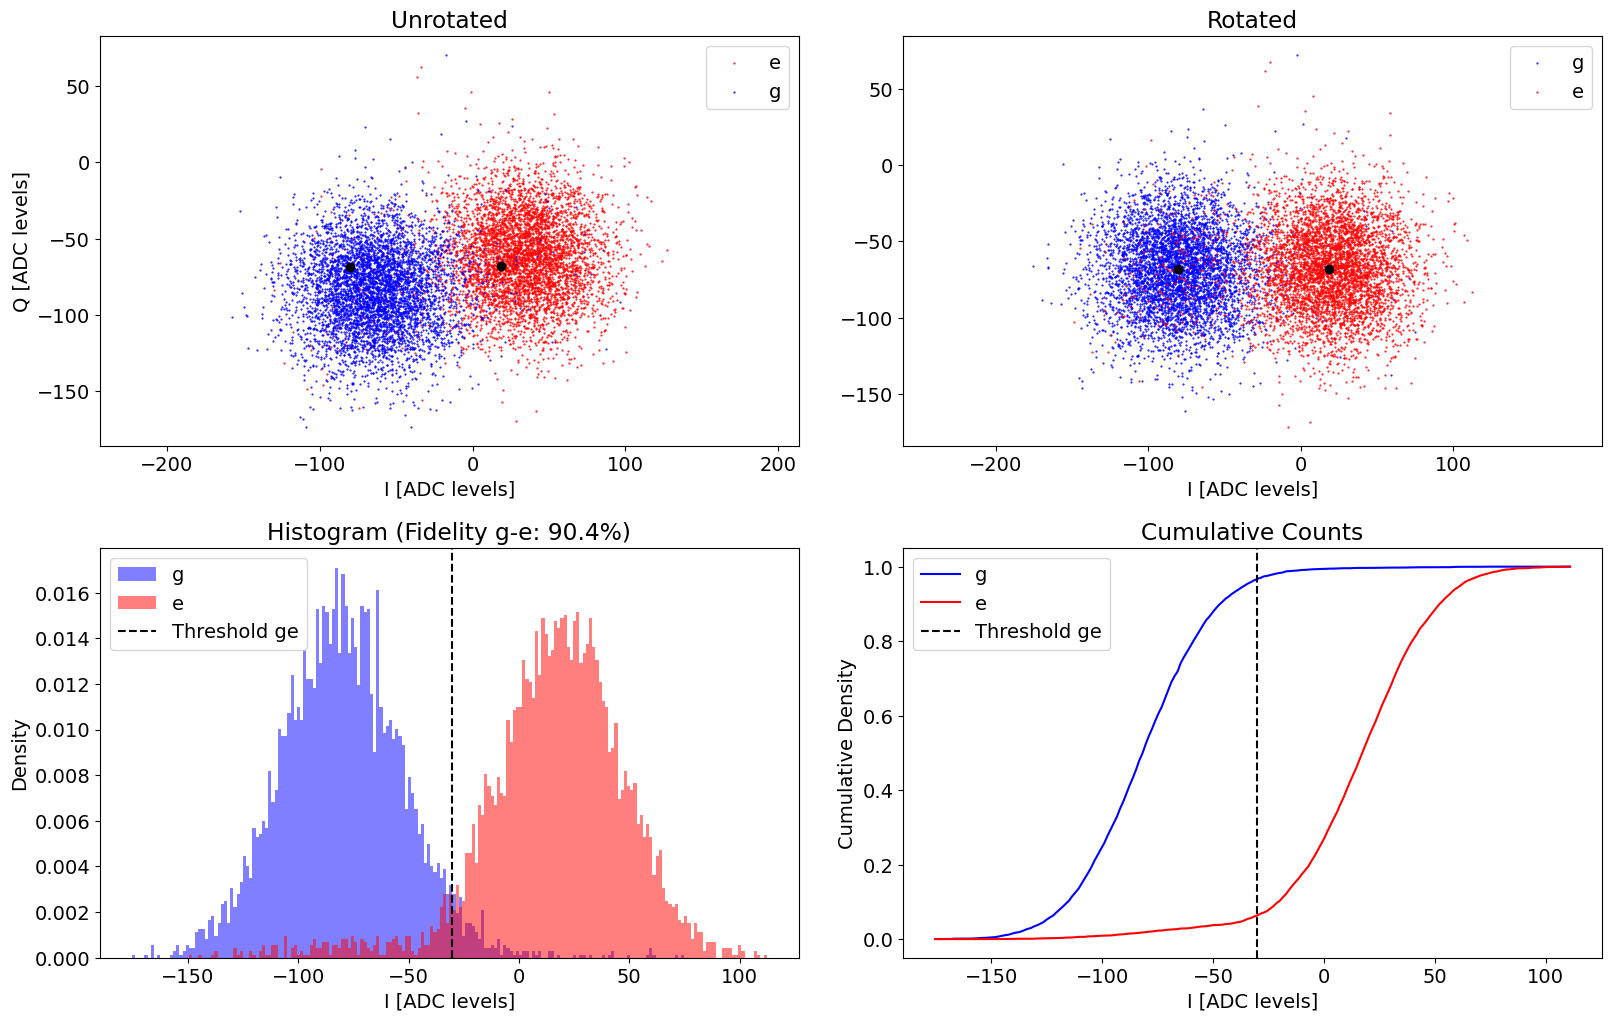

Plot saved to D:\experiments\260511_qsim_darkmode\plots\2026-05-21_10-15-49_histogram.png
Plot reference appended to D:\experiments\260511_qsim_darkmode\logs\2026-05-21.md
ge fidelity (%): 90.36000000000004
rotation angle (deg): -12.121662817937901
threshold ge: -30.094827811778174


In [7]:
# Execute
# =================================
ss_runner = CharacterizationRunner(
    station = station,
    ExptClass = meas.HistogramExperiment,
    default_expt_cfg = singleshot_defaults,
    postprocessor = singleshot_postproc,
    job_client=client,
)

ss = ss_runner.execute(
    check_f=False,
    active_reset=False, # on recalibration of readout, turn off active reset because it will be wrong for selecting when to apply the qubit pulse
    relax_delay=2000,
    # active_reset=True,
    # relax_delay=200,
    priority=1,
)
ss.display(station)

In [8]:
station.update_all_station_snapshots()

[CONFIG] Created new hardware_config version CFG-HW-20260521-00003
[CONFIG] Reusing existing multiphoton_config version CFG-MP-20260121-00001
[CONFIG] Reusing existing man1_storage_swap version CFG-M1-20260519-00015
[CONFIG] Reusing existing floquet_storage_swap version CFG-FL-20260520-00002
Config snapshots for current station:
  hardware_config: CFG-HW-20260521-00003
  multiphoton_config: CFG-MP-20260121-00001
  man1_storage_swap: CFG-M1-20260519-00015
  floquet_storage_swap: CFG-FL-20260520-00002


{'hardware_config': 'CFG-HW-20260521-00003',
 'multiphoton_config': 'CFG-MP-20260121-00001',
 'man1_storage_swap': 'CFG-M1-20260519-00015',
 'floquet_storage_swap': 'CFG-FL-20260520-00002'}

In [ ]:
station.snapshot_hardware_config(update_main=False)
station.preview_config_update()

# Floquet pulse calibrations

## Freq chevron

In [ ]:
station.ds_floquet.df

In [ ]:
station.ds_floquet.update_len('M1-S4', 10)

In [ ]:
# not ideal but qsim base (to be precise, the us2cycles) wants all the lengths to be valid and not NaN
for i in range(2,7):
    station.ds_floquet.update_len(f'M1-S{i}', 0)

In [ ]:
floquet_freq_chev_defaults = AttrDict(dict(
    expts = 1,
    reps = 100,
    rounds = 1,
    qubits = [0],
    ro_stor = 0, # storage mode number that gets read out in the end
    f0g1_cavity = 1,  #  1/2 name of manipulate cavity
    # if 0, this means to read out man instead
    detunes=np.linspace(-0.3, 0.3, 11).tolist(),
    swept_params = ['detune', 'length'],
    normalize = False,
    active_reset = False,
    man_reset = False, 
    storage_reset = False, 
    prepulse=True,
    postpulse=True,
    init_fock=True,
)) # Shouldn't be modifying this on the fly!
# You can use kwargs in the run function to override these values

def floquet_freq_chev_preproc(station, default_expt_cfg, **kwargs):
    assert 'init_stor' in kwargs
    expt_cfg = deepcopy(default_expt_cfg)
    ds_floquet = station.ds_floquet
    init_stor = kwargs.pop('init_stor') # storage mode number to initialize to n=1 Fock state
    lengths = np.linspace(0.01, 3.0 * ds_floquet.get_len(f'M1-S{init_stor}'), 10).tolist()

    expt_cfg.init_stor = init_stor
    expt_cfg.lengths = lengths
    expt_cfg.update(kwargs)
    print(expt_cfg)
    return expt_cfg

def floquet_freq_chev_postproc(station, expt):
    expt_cfg = expt.cfg.expt
    stor_name = f'M{expt_cfg.f0g1_cavity}-S{expt_cfg.init_stor}'

    from fitting.fit_display_classes import ChevronFitting

    chevron_analysis = ChevronFitting(
        frequencies=np.array(expt.data['ypts']),
        time=np.array(expt.data['xpts']),
        response_matrix=expt.data['avgi'],
        config=station.hardware_cfg,
        station=station,
    )

    chevron_analysis.analyze()
    
    best_detune = chevron_analysis.results.get('best_frequency_contrast')

    if best_detune is not None:
        pi_frac = station.ds_floquet.get_pi_frac(stor_name)
        print(f"Best detune found: {best_detune:.4f} MHz")
        current_freq = station.ds_floquet.get_freq(stor_name)
        new_freq = current_freq + best_detune
        station.ds_floquet.update_freq(stor_name, new_freq)
        print(f"Updated {stor_name} frequency to {new_freq:.4f} MHz")
        frac_pi_len = abs(np.pi / chevron_analysis.results['best_fit_params_period']['omega'])
        station.ds_floquet.update_len(stor_name, frac_pi_len)
        print(f'Updated the pi/{pi_frac} length from {station.ds_floquet.get_len(stor_name):.4f} to {frac_pi_len:.4f}')
    
    chevron_analysis.display_results()
    expt.analysis = chevron_analysis
    station.snapshot_floquet_storage_swap(update_main=False)

In [ ]:
stor_modes_to_run = [6] #list(range(1,8))
freq_len_expt = [None] * len(stor_modes_to_run)

floquet_freq_chev_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.FloquetChevronExperiment,
    ExptProgram=meas.FloquetChevronProgram,
    default_expt_cfg=floquet_freq_chev_defaults,
    preprocessor=floquet_freq_chev_preproc,
    postprocessor=floquet_freq_chev_postproc,
    job_client=client,
)

for i, init_stor in enumerate(stor_modes_to_run):
    # ds_floquet.update_gain(f'M1-S{init_stor}', ds_floquet.get_gain(f'M1-S{init_stor}') * 0.75)
    # print(f'Updating gain for M1-S{init_stor} to {ds_floquet.get_gain(f"M1-S{init_stor}")}')

    print(f'Running Floquet Frequency vs Length Chevron for Storage Mode {init_stor}')
    freq_len_expt[i] = floquet_freq_chev_runner.execute(
        init_stor=init_stor,
        detunes=np.linspace(-0.15, 0.15, 31).tolist(),
        relax_delay=8000,
        reps=50,
    )
    freq_len_expt[i].display()
    # clear_output(wait=True)

In [ ]:
freq_len_expt[0].data

In [ ]:
plt.plot(freq_len_expt[0].data['avgi'][5])

In [ ]:
station.ds_floquet.df

In [ ]:
for i in range(len(stor_modes_to_run)):
    floquet_freq_chev_postproc(station, freq_len_expt[i])

## Detuning - Gain Chevron

In [ ]:
floquet_freq_chev_defaults = AttrDict(dict(
    expts = 1,
    reps = 100,
    rounds = 1,
    qubits = [0],
    ro_stor = 0, # storage mode number that gets read out in the end
    f0g1_cavity = 1,  #  1/2 name of manipulate cavity
    # if 0, this means to read out man instead
    detunes=np.linspace(-0.3, 0.3, 11).tolist(),
    swept_params = ['detune', 'gain'],
    normalize = False,
    active_reset = False,
    man_reset = False, 
    storage_reset = False, 
    prepulse=True,
    postpulse=True,
    init_fock=True,
)) # Shouldn't be modifying this on the fly!
# You can use kwargs in the run function to override these values

def floquet_freq_chev_preproc(station, default_expt_cfg, **kwargs):
    assert 'init_stor' in kwargs
    expt_cfg = deepcopy(default_expt_cfg)
    ds_floquet = station.ds_floquet
    init_stor = kwargs.pop('init_stor') # storage mode number to initialize to n=1 Fock state
    gains = np.linspace(0.01, 3.0 * ds_floquet.get_gain(f'M1-S{init_stor}'), 200).tolist()

    expt_cfg.init_stor = init_stor
    expt_cfg.gains = gains
    expt_cfg.update(kwargs)
    print(expt_cfg)
    return expt_cfg

def floquet_freq_chev_postproc(station, expt):
    expt_cfg = expt.cfg.expt
    stor_name = f'M{expt_cfg.f0g1_cavity}-S{expt_cfg.init_stor}'

    from fitting.fit_display_classes import ChevronFitting

    chevron_analysis = ChevronFitting(
        frequencies=np.array(expt.data['ypts']),
        time=np.array(expt.data['xpts']),
        response_matrix=expt.data['avgi'],
        config=station.hardware_cfg,
        station=station,
    )

    chevron_analysis.analyze()
    
    best_detune = chevron_analysis.results.get('best_frequency_contrast')

    if best_detune is not None:
        pi_frac = station.ds_floquet.get_pi_frac(stor_name)
        print(f"Best detune found: {best_detune:.4f} MHz")
        current_freq = station.ds_floquet.get_freq(stor_name)
        new_freq = current_freq + best_detune
        station.ds_floquet.update_freq(stor_name, new_freq)
        print(f"Updated {stor_name} frequency to {new_freq:.4f} MHz")
        frac_pi_len = abs(np.pi / chevron_analysis.results['best_fit_params_period']['omega'])
        station.ds_floquet.update_len(stor_name, frac_pi_len)
        print(f'Updated the pi/{pi_frac} length from {station.ds_floquet.get_len(stor_name):.4f} to {frac_pi_len:.4f}')
    
    chevron_analysis.display_results()
    expt.analysis = chevron_analysis
    station.snapshot_floquet_storage_swap(update_main=False)

In [ ]:
stor_modes_to_run = [3] #list(range(1,8))
freq_len_expt = [None] * len(stor_modes_to_run)

floquet_freq_chev_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.qsim.t2_cavity_fluxexcursion.FloquetAmpChevronExperiment,
    ExptProgram=meas.qsim.t2_cavity_fluxexcursion.FloquetChevronAmpProgram,
    default_expt_cfg=floquet_freq_chev_defaults,
    preprocessor=floquet_freq_chev_preproc,
    # postprocessor=floquet_freq_chev_postproc,
    job_client=client,
)

for i, init_stor in enumerate(stor_modes_to_run):
    # ds_floquet.update_gain(f'M1-S{init_stor}', ds_floquet.get_gain(f'M1-S{init_stor}') * 0.75)
    # print(f'Updating gain for M1-S{init_stor} to {ds_floquet.get_gain(f"M1-S{init_stor}")}')

    print(f'Running Floquet Frequency vs Gain Chevron for Storage Mode {init_stor}')
    freq_len_expt[i] = floquet_freq_chev_runner.execute(
        init_stor=init_stor,
        # detunes=np.linspace(-1.0, 1.0, 21).tolist(),
        relax_delay=8000,
        reps=50,
    )
    freq_len_expt[i].display()
    # clear_output(wait=True)

In [ ]:
station.ds_floquet.df

## Error amplification on floquet pulses

In [ ]:
error_amp_floquet_defaults = AttrDict(dict(
    reps=100,
    rounds=1,
    qubits=[0],
    active_reset=False,
    man_mode_no=1,
    stor_is_dump=False,
    man_reset=True,
    storage_reset=True,
    relax_delay=2500, 
    expts=25,
    qubit_start_storage='g',
)) # Shouldn't be modifying this on the fly!
# You can use kwargs in the run function to override these values

error_amp_gain_floquet_coarse_defaults = AttrDict(dict(
    n_pulses=8,
    span=4000,#4000
    expts=30,#30
))

error_amp_freq_floquet_coarse_defaults = AttrDict(dict(
    n_pulses=7,
    span=0.25,
    expts=50,
))


def error_amp_floquet_preproc(station, default_expt_cfg, **kwargs):
    assert 'stor_mode_no' in kwargs
    assert 'parameter_to_test' in kwargs 

    # construct the defaults
    expt_cfg = deepcopy(default_expt_cfg)
    if kwargs['parameter_to_test'] == 'gain':
        expt_cfg.update(error_amp_gain_floquet_coarse_defaults)
    elif kwargs['parameter_to_test'] == 'frequency':
        expt_cfg.update(error_amp_freq_floquet_coarse_defaults)
    # override with the passed kwargs
    expt_cfg.update(kwargs)

    freq, gain, length, pi_frac, ch, prepulse, postpulse = get_floquet_parameters(station, expt_cfg.man_mode_no, expt_cfg.stor_mode_no)
    pulse_type = ['floquet', f'M{expt_cfg.man_mode_no}-{"D" if expt_cfg.stor_is_dump else "S"}{expt_cfg.stor_mode_no}', f'pi/{pi_frac}', 0]
    # freq = 695.7
    # gain = 10000
    if expt_cfg.parameter_to_test == 'frequency':
        start = freq - expt_cfg.span / 2
        step = expt_cfg.span / (expt_cfg.expts - 1)
    elif expt_cfg.parameter_to_test == 'gain':
        start = int(gain - expt_cfg.span / 2)
        step = int(expt_cfg.span / (expt_cfg.expts - 1))
    else:
        raise ValueError("parameter_to_test must be either 'frequency' or 'gain'.")
    expt_cfg.start = start
    expt_cfg.step = step
    expt_cfg.pulse_type = pulse_type 
    return expt_cfg

def error_amp_floquet_postproc(station, expt):
    expt.analyze(data=expt.data, state_fin='e')

    opt_val = expt.data['fit_avgi'][2]
    stor_name = 'M1-S' + str(expt.cfg.expt.stor_mode_no)
    if expt.cfg.expt.parameter_to_test == 'gain':
        station.ds_floquet.update_gain(stor_name, opt_val)
        print(f'Updated gain for {stor_name} to {opt_val}')
    elif expt.cfg.expt.parameter_to_test == 'frequency':
        station.ds_floquet.update_freq(stor_name, opt_val)
        print(f'Updated frequency for {stor_name} to {opt_val}')
    station.snapshot_floquet_storage_swap(update_main=False)


error_amp_floquet_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.single_qubit.error_amplification.ErrorAmplificationExperiment,
    default_expt_cfg=error_amp_floquet_defaults,
    preprocessor=error_amp_floquet_preproc,
    postprocessor=error_amp_floquet_postproc,
    job_client=client,
)

In [ ]:
stor_modes_to_run = [2] #list(range(1,8))
error_amp_gain1 = [None] * len(stor_modes_to_run)
error_amp_freq1 = [None] * len(stor_modes_to_run)
error_amp_gain2 = [None] * len(stor_modes_to_run)
error_amp_freq2 = [None] * len(stor_modes_to_run)

In [ ]:
stor_modes_to_run

### Coarse

In [ ]:
for i, stor_i in enumerate(stor_modes_to_run):
    stor_name = 'M1-S' + str(stor_i)
    print("Running", stor_name)
    error_amp_freq1[i] = error_amp_floquet_runner.execute(
        stor_mode_no=stor_i,
        parameter_to_test='frequency',
        go_kwargs=dict(analyze=False, progress=True, display=False),
        span = 0.02 # 0.2 is default, but we want to be more precise since we are already close
    )
    error_amp_freq1[i].display()

    error_amp_gain1[i] = error_amp_floquet_runner.execute(
        stor_mode_no=stor_i,
        parameter_to_test='gain',   
        go_kwargs=dict(analyze=False, progress=True, display=False),
        span=int(station.ds_floquet.get_gain(stor_name) * 0.2), #0.7 is default
        # span = 59,
        expts = 60
        # expts=60,
    )
    error_amp_gain1[i].display()

In [ ]:
station.ds_floquet.update_freq('M1-S5', 1051.965)

In [ ]:
station.ds_floquet.df

In [ ]:
station.snapshot_floquet_storage_swap(update_main=False)

### Fine

In [ ]:
error_amp_freq_floquet_fine_defaults = AttrDict(dict(
        n_pulses=7,
        span=0.15,
        expts=50,
))

error_amp_gain_floquet_fine_defaults = AttrDict(dict(
        n_pulses=10,
        expts=40,
))

In [ ]:
for i, stor_i in enumerate(stor_modes_to_run):
    stor_name = 'M1-S' + str(stor_i)
    print("Running", stor_name)

    error_amp_freq2[i] = error_amp_floquet_runner.run(
        stor_mode_no=stor_i,
        parameter_to_test='frequency',
        go_kwargs=dict(analyze=False, progress=True, display=False),
        **error_amp_freq_floquet_fine_defaults,
    )

    error_amp_gain2[i] = error_amp_floquet_runner.run(
        stor_mode_no=stor_i,
        parameter_to_test='gain',
        go_kwargs=dict(analyze=False, progress=True, display=False),
        span=int(station.ds_floquet.get_gain(stor_name) * 0.15),
        **error_amp_gain_floquet_fine_defaults,
    )

In [ ]:
error_amp_freq2[1].display()

In [ ]:
error_amp_gain2[0].display()

In [ ]:
station.update_all_station_snapshots()

## Phase accumulation matrix from stark shifts

In [5]:
phase_expts = [[None for _ in range(7)] for _ in range(7)]

In [6]:
sideband_stark_error_amp_defaults = AttrDict(dict(
    expts=1,
    reps=100,
    rounds=1,
    qubits=[0],
    f0g1_cavity=1,  #  1/2 name of manipulate cavity
    init_stor=0, # storage mode number to initialize to n=1 Fock state (0=man)
    ro_stor=0, # storage mode number that gets read out in the end (0=man)
    advance_phases=np.linspace(-15, 15, 51).tolist(),
    n_pulses=np.arange(0, 24, 4).tolist(),
    swept_params=['n_pulse', 'advance_phase'],
    normalize=False, # not sure what this does
    active_reset=False,
    man_reset=False, 
    storage_reset=False, 
    prepulse=True,
    postpulse=True,
    init_fock=True,
))

def sideband_stark_error_amp_preproc(station, default_expt_cfg, **kwargs):
    assert 'stor_A' in kwargs
    assert 'stor_B' in kwargs

    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)
    print(expt_cfg)
    return expt_cfg

def sideband_stark_error_amp_postproc(station, expt):
    storA = expt.cfg.expt.stor_A
    storB = expt.cfg.expt.stor_B
    stor_name = 'M1-S' + str(storA)
    from_stor_name = 'M1-S' + str(storB)
    expt.analyze(fit=True)
    expt.display(fit=True)
    # opt_phase = expt.data['fit_avgi'][2] / 2 # divide by 2 since did pi/12, -pi/12 on the from_stor swap
    opt_phase = expt.data['fit_avgi'][2] # not dividing seems to give the correct result somehow? TODO: figure out why
    print("Opt phase on", stor_name, "from", from_stor_name, ":", opt_phase)
    station.ds_floquet.update_phase_from(stor_name, from_stor_name, opt_phase)
    station.snapshot_floquet_storage_swap(update_main=False)

sideband_stark_error_amp_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.SidebandStarkAmplificationExperiment,
    ExptProgram=meas.qsim.floquet_dark_mode_readout.SidebandStarkAmplificationModifiedProgram, #meas.SidebandStarkAmplificationProgram,
    default_expt_cfg=sideband_stark_error_amp_defaults,
    preprocessor=sideband_stark_error_amp_preproc,
    postprocessor=sideband_stark_error_amp_postproc,
    job_client=client,
)

Starting experiment for storage modes: 1 from 6
{'expts': 1, 'reps': 50, 'rounds': 1, 'qubits': [0], 'f0g1_cavity': 1, 'init_stor': 0, 'ro_stor': 0, 'advance_phases': [-15.0, -14.4, -13.8, -13.2, -12.6, -12.0, -11.4, -10.8, -10.2, -9.600000000000001, -9.0, -8.4, -7.800000000000001, -7.2, -6.6, -6.0, -5.4, -4.800000000000001, -4.200000000000001, -3.5999999999999996, -3.0, -2.4000000000000004, -1.8000000000000007, -1.200000000000001, -0.6000000000000014, 0.0, 0.5999999999999996, 1.1999999999999993, 1.8000000000000007, 2.3999999999999986, 3.0, 3.599999999999998, 4.199999999999999, 4.800000000000001, 5.399999999999999, 6.0, 6.599999999999998, 7.199999999999999, 7.800000000000001, 8.399999999999999, 9.0, 9.599999999999998, 10.2, 10.8, 11.399999999999999, 12.0, 12.599999999999998, 13.2, 13.799999999999997, 14.399999999999999, 15.0], 'n_pulses': [0, 4, 8, 12, 16, 20], 'swept_params': ['n_pulse', 'advance_phase'], 'normalize': False, 'active_reset': False, 'man_reset': False, 'storage_reset': 

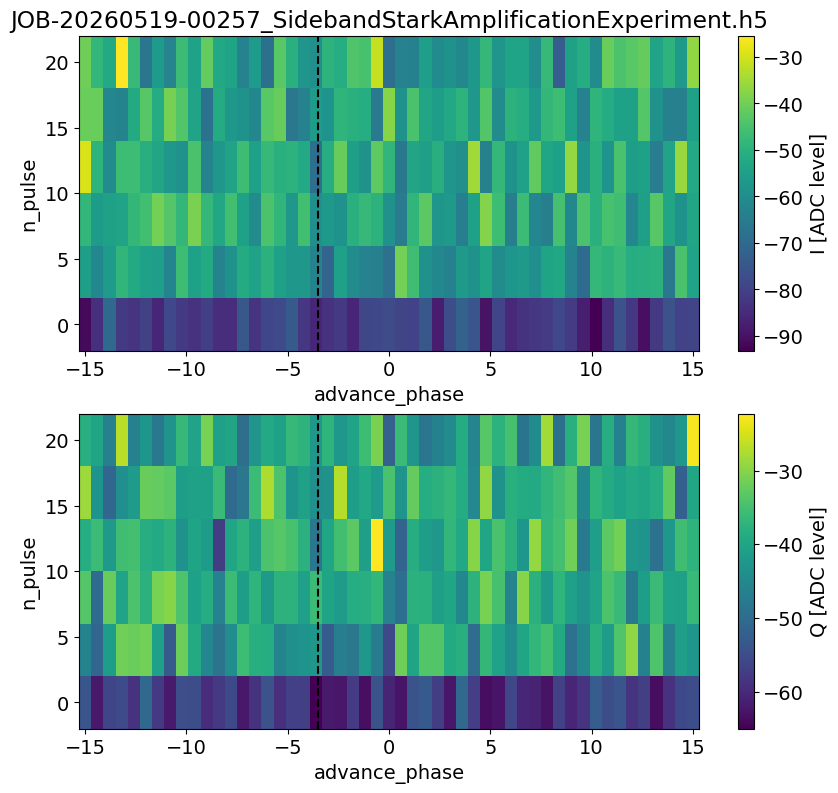

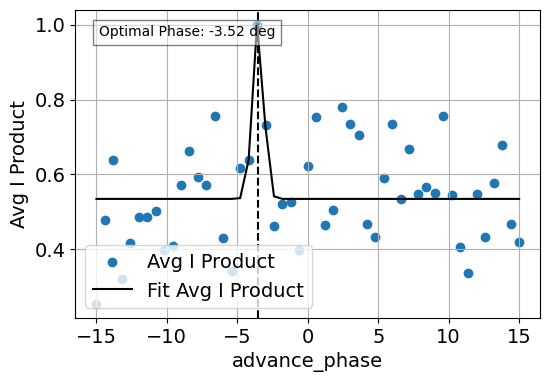

Opt phase on M1-S1 from M1-S6 : -3.5240989647935503
[CONFIG] Created new floquet_storage_swap version CFG-FL-20260519-00070
Starting experiment for storage modes: 6 from 1
{'expts': 1, 'reps': 50, 'rounds': 1, 'qubits': [0], 'f0g1_cavity': 1, 'init_stor': 0, 'ro_stor': 0, 'advance_phases': [-15.0, -14.4, -13.8, -13.2, -12.6, -12.0, -11.4, -10.8, -10.2, -9.600000000000001, -9.0, -8.4, -7.800000000000001, -7.2, -6.6, -6.0, -5.4, -4.800000000000001, -4.200000000000001, -3.5999999999999996, -3.0, -2.4000000000000004, -1.8000000000000007, -1.200000000000001, -0.6000000000000014, 0.0, 0.5999999999999996, 1.1999999999999993, 1.8000000000000007, 2.3999999999999986, 3.0, 3.599999999999998, 4.199999999999999, 4.800000000000001, 5.399999999999999, 6.0, 6.599999999999998, 7.199999999999999, 7.800000000000001, 8.399999999999999, 9.0, 9.599999999999998, 10.2, 10.8, 11.399999999999999, 12.0, 12.599999999999998, 13.2, 13.799999999999997, 14.399999999999999, 15.0], 'n_pulses': [0, 4, 8, 12, 16, 20], 's

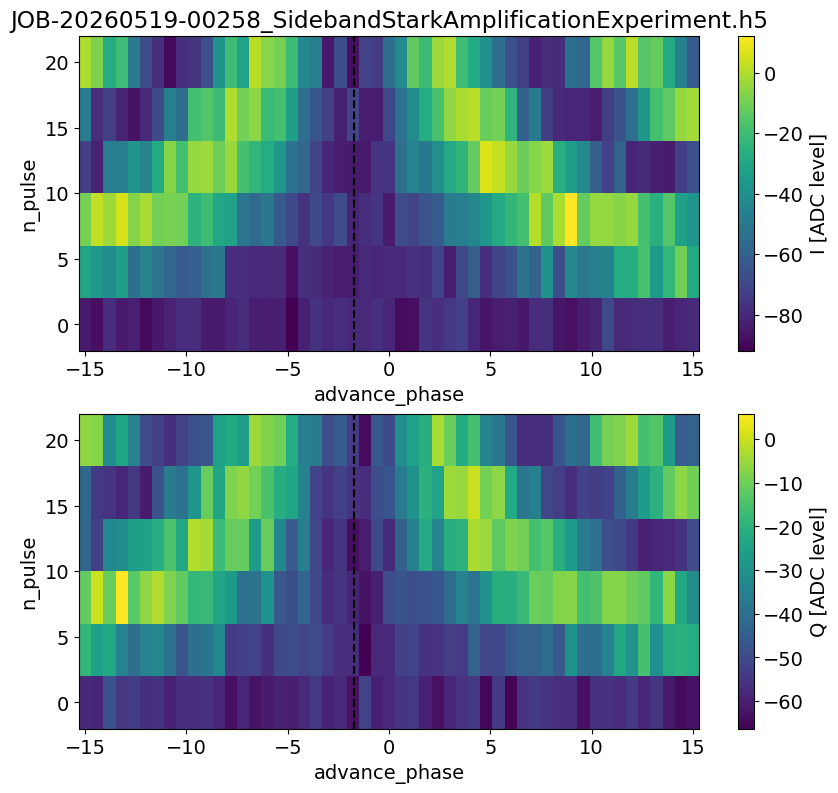

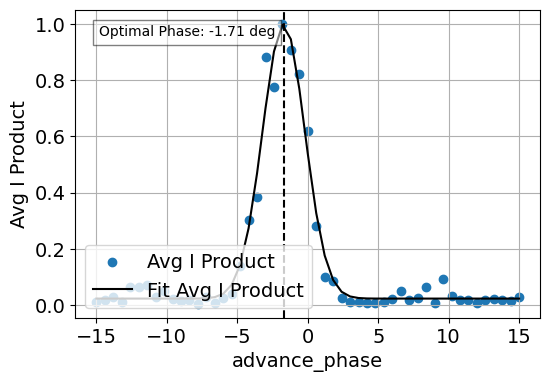

Opt phase on M1-S6 from M1-S1 : -1.7077036154360492
[CONFIG] Created new floquet_storage_swap version CFG-FL-20260519-00071


In [38]:
stor_modes_to_run = [1, 6] #list(range(1,8))

for iA, init_storA in enumerate(stor_modes_to_run): #range(1,8):
    for iB, init_storB in enumerate(stor_modes_to_run): #range(1,8):
        if init_storA == init_storB:
            continue
        print("Starting experiment for storage modes:", init_storA, "from", init_storB)

        qbe = sideband_stark_error_amp_runner.execute(
            stor_A=init_storA,
            stor_B=init_storB,
            relax_delay=8000,
            reps=50,
            include_10cycles_buffer = True,
            advance_phases=np.linspace(-15, 15, 51).tolist(),
        )
        phase_expts[init_storA - 1][init_storB - 1] = qbe

Starting experiment for storage modes: 1 from 6
{'expts': 1, 'reps': 50, 'rounds': 1, 'qubits': [0], 'f0g1_cavity': 1, 'init_stor': 0, 'ro_stor': 0, 'advance_phases': [-40.0, -38.4, -36.8, -35.2, -33.6, -32.0, -30.4, -28.799999999999997, -27.2, -25.6, -24.0, -22.4, -20.799999999999997, -19.2, -17.599999999999998, -16.0, -14.399999999999999, -12.799999999999997, -11.2, -9.599999999999998, -8.0, -6.399999999999999, -4.799999999999997, -3.1999999999999957, -1.5999999999999943, 0.0, 1.6000000000000014, 3.200000000000003, 4.800000000000004, 6.400000000000006, 8.0, 9.600000000000001, 11.200000000000003, 12.800000000000004, 14.400000000000006, 16.0, 17.6, 19.200000000000003, 20.800000000000004, 22.400000000000006, 24.0, 25.60000000000001, 27.200000000000003, 28.799999999999997, 30.400000000000006, 32.0, 33.60000000000001, 35.2, 36.80000000000001, 38.400000000000006, 40.0], 'n_pulses': [0, 4, 8, 12, 16, 20], 'swept_params': ['n_pulse', 'advance_phase'], 'normalize': False, 'active_reset': Fals


[2.2s] Job JOB-20260519-00261: running
[WORKER] Loading SidebandStarkAmplificationExperiment from experiments.qsim.sideband_stark
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260519-00261_SidebandStarkAmplificationExperiment.h5
[WORKER]   Program: SidebandStarkAmplificationModifiedProgram from experiments.qsim.floquet_dark_mode_readout
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.3mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 83%|████████████████████████████████████▋       | 5/6 [02:13<00:26, 26.69s/it]
[167.2s] Job JOB-20260519-00261: completed
100%|████████████████████████████████████████████| 6/6 [02:40<00:00, 26.69s/it]
Saving D:\experiments\260511_qsim_darkmode\data\JOB-20260519-00261_SidebandStarkAmplificationExperiment.h5
[WORKER] Saving expt object to: D:\experiments\260511_qsim_darkmode\expt_objs\JOB-20260519-00261_expt.pkl

Job completed! Data: D:\experiments\260511_qsim_darkmode\data\JOB-2026051

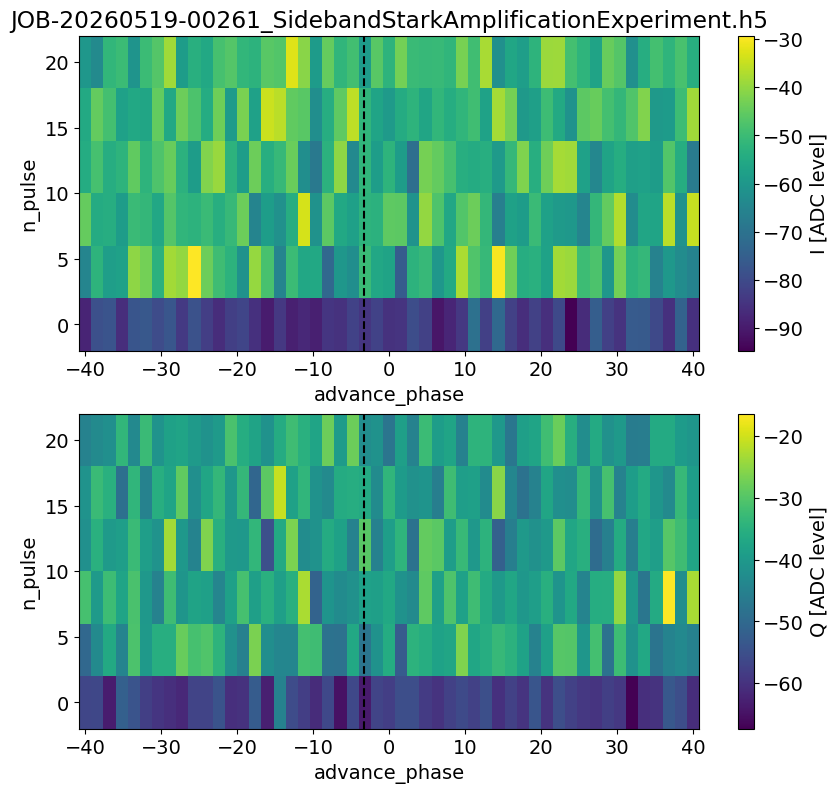

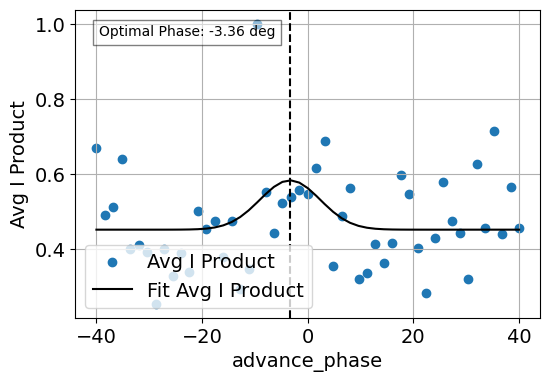

Opt phase on M1-S1 from M1-S6 : -3.3553593516917246
[CONFIG] Created new floquet_storage_swap version CFG-FL-20260519-00074


In [41]:
stor_modes_to = [1] #list(range(1,8))
stor_modes_from = [6]
for iA, init_storA in enumerate(stor_modes_to): #range(1,8):
    for iB, init_storB in enumerate(stor_modes_from): #range(1,8):
        if init_storA == init_storB:
            continue
        print("Starting experiment for storage modes:", init_storA, "from", init_storB)

        qbe = sideband_stark_error_amp_runner.execute(
            stor_A=init_storA,
            stor_B=init_storB,
            relax_delay=8000,
            reps=50,
            include_10cycles_buffer = True,
            advance_phases=np.linspace(-40, 40, 51).tolist(),
            n_pulses=np.arange(0, 24, 4).tolist(),
        )
        phase_expts[init_storA - 1][init_storB - 1] = qbe

In [43]:
station.snapshot_floquet_storage_swap(update_main=False)

[CONFIG] Reusing existing floquet_storage_swap version CFG-FL-20260519-00074


'CFG-FL-20260519-00074'

In [ ]:
station.ds_floquet.update_len('M1-S4', 0.065348)

In [ ]:
station.snapshot_floquet_storage_swap()

In [ ]:
station.update_all_station_snapshots()

# AC Stark calibration with pi/2 dual rail

In [ ]:
expt_params = dict(
    expts = 1,
    reps = 100,
    rounds = 1,
    qubits = [0],
    f0g1_cavity = 1,  #  1/2 name of manipulate cavity
    init_stor = 0, # storage mode number to initialize to n=1 Fock state
    ro_stor = 0, # storage mode number that gets read out in the end
    stor_row = 3,
    stor_col = 2,
    stor_idle = 1,
    # if 0, this means to read out man instead
    # detunes=np.linspace(-0.2, 0.2, 10).tolist(),
    # lengths=np.linspace(0, 1.5 * ds_thisrun.get_len(f'M1-S{init_stor}'), 10).tolist(),
    # swept_params = ['detune', 'length'],
    advance_phases=np.linspace(-90,90,31).tolist(),
    lengths=np.linspace(0.1, 50, 51).tolist(),
    swept_params = ['advance_phase', 'length'],
    # usage: if you want to sweep cfg.expt.paramName, 
    # include paramName here in this list 
    # AND include cfg.expt.paramNames (note the s) as a list of values to step thru.
    # (You want a list instead of numpy array for better yaml export.)
    # Currently handles 1D and 2D sweeps and plots only.
    # For 2D, order is [outer, inner].
    normalize = False,
    active_reset = False,
    man_reset = True, 
    storage_reset = True, 
    ds_thisrun=ds_thisrun,
)

qbe = meas.FloquetPhaseCalExperiment(
    soccfg=soc,
    path=expt_path,
    prefix=f"FloquetPhaseCal_{expt_params['stor_col']}on{expt_params['stor_row']}_via{expt_params['stor_idle']}",
    config_file=config_path,
    expt_params=expt_params,
    program=meas.FloquetPhaseCalProgram,
    progress=True)

qbe.cfg.device.readout.relax_delay = [8000]  # Wait time between experiments [us]
qbe.go(analyze=False, display=True, progress=True, save=True)
# freq_len_expt[i] = qbe

## Use the period of the 2 storage + M1 random walk to error amplify the phase calibration

In [ ]:
# storA = 2
# storB = 3

for storA, storB in [(2,3),(2,6),(3,6),(2,7),(3,7),(6,7)]:
    print("Starting experiment for storage modes:", storA, "from", storB)
    n_scramble_cycles = [0,1,2,3]
    pifracA, pifracB = ds_thisrun.get_pi_frac(f'M1-S{storA}'), ds_thisrun.get_pi_frac(f'M1-S{storB}')
    n_floquet_per_scramble = int(np.round(2*(pifracA**2 + pifracB**2)**0.5))
    # = for omega1=omega2 the period is 2sqrt(2) * pi_frac

    floquet_cycles = n_floquet_per_scramble * n_scramble_cycles

    expt_params = dict(
        expts = 1,
        reps = 50,
        rounds = 1,
        qubits = [0],
        f0g1_cavity = 1,  #  1/2 name of manipulate cavity
        init_stor = storA, # storage mode number to initialize to n=1 Fock state (0 = man)
        ro_stor = storB, # storage mode number that gets read out in the end (0 = man)
        storA = storA, # storage mode on whose phase accumulation we will evaluate (relative to the stark shifted frequency)
        storB = storB, # storage mode on which a drive is applied which contributes the phase accumulation
        storA_advance_phases = np.linspace(-15, 15, 61).tolist(),
        storB_advance_phases = np.linspace(-15, 15, 61).tolist(),
        n_scramble_cycles = n_scramble_cycles,
        n_floquet_per_scramble = n_floquet_per_scramble,
        # usage: if you want to sweep cfg.expt.paramName, 
        # include paramName here in this list 
        # AND include cfg.expt.paramNames (note the s) as a list of values to step thru.
        # (You want a list instead of numpy array for better yaml export.)
        # Currently handles 1D and 2D sweeps and plots only.
        # For 2D, order is [outer (y), inner (x)].
        normalize = False, # not sure what this does
        active_reset = False,
        man_reset = True, 
        storage_reset = True, 
        ds_thisrun=ds_thisrun,
        prepulse=True,
        postpulse=True,
    )
    print("n_scramble_cycles", expt_params["n_scramble_cycles"])
    print("phase sweep A", expt_params["storA_advance_phases"])
    print("phase sweep B", expt_params["storB_advance_phases"])

    qbe = meas.FloquetCalibrationAmplificationExperiment(
        soccfg=soc,
        path=expt_path,
        prefix=f"FloquetCalibrationAmplificationExperiment_S{expt_params['storA']}_S{expt_params['storB']}",
        config_file=config_path,
        expt_params=expt_params,
        program=meas.FloquetCalibrationProgram,
        progress=True)

    qbe.cfg.device.readout.relax_delay = [8000]  # Wait time between experiments [us]
    qbe.acquire(progress=True, debug=True)
    qbe.save_data()

In [ ]:
qbe.save_data()
# qbe.analyze()

# Photon number scrambling

## Sideband Ramsey

This is starting to test our channel phases: when we switch from one channel generator freq to diff freq (activating different storage swaps), does our code preserve phase coherence between the successive (partial) pulses. 

We start from a simple M1-Sx Ramsey: qubit ge, qubit ef, f0g1 to initialize man1 into |1>, then do pi/2 on the beam splitter and wait and another pi/2.

In [ ]:
expt_params = dict(
    start = 0.01, # wait time tau [us]
    step = 0.1,  # [us] 1 cycle is 0.0023251488095238095 [us], 2.7901785714285716 # [us]=1200 cycles
    expts = 100,
    ramsey_freq = 0.2, # [MHz]
    detune = 0,
    ac_stark=0.5, # [MHz] not sure how to define sign yet
    # but in any case this needs to be smaller than ramsey_freq
    # because qick can't handle negative numbers
    reps = 100,
    rounds = 1,
    qubits = [0],
    f0g1_cavity = 1,  #  1/2 name of manipulate cavity
    stor_no = 1, # storage mode number, 1 to 7
    normalize = False,
    active_reset = True,
    man_reset = True, 
    storage_reset = True, 
    advance_phase = 0, # advance phase of second pi/2 by this much [degrees]
    echoes = [False, 0], # [on/off, number of echoes]
)

sbr = SidebandRamseyExperiment(
    soccfg=soc,
    path=expt_path,
    prefix=f"SidebandRamsey_M1S{expt_params['stor_no']}",
    config_file=config_path,
    expt_params = expt_params,
    progress=True)

sbr.cfg.device.readout.relax_delay = [200]  # Wait time between experiments [us]
# sbr.acquire()
sbr.go(analyze=True, display=True, progress=True, save=True)

In [ ]:
idata = sbr.data['idata']
idata = idata.reshape((len(idata)//4,4))

qdata = sbr.data['qdata']
qdata = qdata.reshape((len(qdata)//4,4))

fig, axs = plt.subplots(nrows=4,ncols=2, figsize=(8,8))
for kk in range(4):
    axs[kk,0].hist(idata[:,kk], bins=100)
    axs[kk,1].hist(qdata[:,kk], bins=100)
None

## Sideband scramble

In [ ]:
sideband_scramble_defaults = AttrDict(dict(
    expts=1,
    reps=100,
    rounds=1,
    qubits=[0],
    ro_stor=0, # storage mode number that gets read out in the end

    init_fock=True,

    normalize=False,
    post_select_pre_pulse=False,
    active_reset=False,
    man_reset=False, 
    storage_reset=False, 
    prepulse=True,
    postpulse=True,
)) # Shouldn't be modifying this on the fly!
# You can use kwargs in the run function to override these values

def sideband_scramble_preproc(station, default_expt_cfg, **kwargs):
    assert 'swept_params' in kwargs
    assert len(kwargs['swept_params']) > 0

    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)
    assert 'init_stor' in kwargs
    if not expt_cfg.init_fock:
        assert 'init_alpha' in kwargs
        
    # print(expt_cfg)
    return expt_cfg


In [ ]:
scramble_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.QsimBaseExperiment,
    ExptProgram=meas.SidebandScrambleProgram,
    default_expt_cfg=sideband_scramble_defaults,
    preprocessor=sideband_scramble_preproc,
    postprocessor=None,
    job_client=client,
)

floquet_cycles = np.arange(0, 51, step=1)

meas_stors = [0,1,2]
swap_stors = [1, 2]
detunings = [0, 0] # None/False/unspecified all default to all zeros

scramble_expts = []

for update_phases in [True]:
    for meas_stor in meas_stors:
        scramble = scramble_runner.execute(
            reps=200,
            init_fock=True,
            init_stor=0,
            ro_stor=meas_stor,
            relax_delay=200,
            active_reset=True,
            man_reset=True, 
            storage_reset = [1,2], 
            reset_dump_mode = 2,
            swap_stors=swap_stors,
            update_phases=update_phases,
            detunings=detunings,
            floquet_cycles=floquet_cycles,
            swept_params=['floquet_cycle'],
        )
        scramble_expts.append(scramble)
        scramble.display()

In [ ]:
fig, ax = plt.subplots(1, 2, figsize = (14, 5))

for scramble_expt in scramble_expts:
    state_idx = scramble_expt.cfg.expt.ro_stor
    state_prefix = "S"
    if state_idx == 0:
        state_prefix = "M"
        state_idx = 1
    ax[0].plot(scramble_expt.data['xpts'], scramble_expt.data['avgi'], label = F"State: {state_prefix}{state_idx}")
    ax[1].plot(scramble_expt.data['xpts'], scramble_expt.data['avgq'], label = F"State: {state_prefix}{state_idx}")
ax[0].set_xlabel("Floquet Cycle")
ax[1].set_xlabel("Floquet Cycle")
ax[0].set_ylabel("Avg I (ADC unit)")
ax[1].set_ylabel("Avg Q (ADC unit)")
ax[0].legend()
ax[1].legend()

In [ ]:
station.ds_storage.df

In [ ]:
meas_stors = [0,1,7]

for update_phases in [True]: # [False, True]:
    for meas_stor in meas_stors:
        expt_params = dict(
            expts = 1,
            reps = 100,
            rounds = 1,
            qubits = [0],
            f0g1_cavity = 1,  #  name of manipulate cavity (1 or 2)
            init_stor = 0, # storage mode number to initialize to n=1 Fock state
            ro_stor = meas_stor, # storage mode number that gets read out in the end
            # if 0, this means to read out man instead
            floquet_cycles = list(range(0,201)),
            detune=0,
            normalize = False,
            active_reset = False,
            man_reset = True, 
            storage_reset = True, 
            # advance_phase=3,
            # swept_params = ['advance_phase', 'floquet_cycle'],
            swept_params = ['floquet_cycle'],
            swap_stors = [1,7],
            # floquet_dataset_filename = 'floquet_storage_2Derramp.csv',
            update_phases = update_phases, 
            echoes = [False, 0], # [on/off, number of echoes]
            prepulse=True,
            postpulse=True,
        )
    
        sbs = meas.QsimBaseExperiment(
            soccfg=soc,
            path=expt_path,
            prefix=f"SidebandScramble_S{expt_params['init_stor']}_to_S{expt_params['ro_stor']}",
            config_file=config_path,
            expt_params = expt_params,
            program = meas.SidebandScrambleProgram,
            progress=True)
    
        sbs.cfg.device.readout.relax_delay = [8000]  # Wait time between experiments [us]
        sbs.go(analyze=False, display=True, progress=True, save=True)

### Phase calibration using quantum walk

In [ ]:
from multimode_expts.experiments.qsim.sideband_scramble import FloquetCalibrationProgram

In [ ]:
storA = 2
storB = 3

expt_params = dict(
    expts = 1,
    reps = 50,
    rounds = 1,
    qubits = [0],
    f0g1_cavity = 1,  #  1/2 name of manipulate cavity
    storA = storA,
    storB = storB,
    init_stor = storA, # storage mode number to initialize to n=1 Fock state
    ro_stor = storB, # storage mode number that gets read out in the end
    # if 0, this means to read out man instead
    floquet_cycles = list(range(1,201,2)), 
    normalize = False,
    active_reset = False,
    man_reset = True, 
    storage_reset = True, 
    storA_advance_phases = np.linspace(-20,20,81).tolist(), # advance phase of each successive pulse for the init mode[degrees]
    storB_advance_phase = ds_thisrun.get_phase_from(f'M1-S{storB}', f'M1-S{storA}')*2,
    # ro_advance_phases = np.linspace(-10,10,101).tolist(), # advance phase of each successive pulse for the ro mode [degrees]
    swept_params = ['storA_advance_phase', 'floquet_cycle'],
    # swept_params = ['floquet_cycle'],
    echoes = [False, 0], # [on/off, number of echoes]
    prepulse=True,
    postpulse=True
)


fce = QsimBaseExperiment(
    soccfg=soc,
    path=expt_path,
    prefix=f"FloquetCalibration_S{expt_params['init_stor']}_to_S{expt_params['ro_stor']}",
    config_file=config_path,
    expt_params = expt_params,
    program = FloquetCalibrationProgram,
    progress=True)

fce.cfg.device.readout.relax_delay = [8000]  # Wait time between experiments [us]
fce.go(analyze=False, display=True, progress=True, save=True)

In [ ]:
for storA, storB in [(2,6),(2,7),(3,2),(3,6),(3,7),(6,2),(6,3),(6,7),(7,2),(7,3),(7,6)]:
    expt_params = dict(
        expts = 1,
        reps = 50,
        rounds = 1,
        qubits = [0],
        f0g1_cavity = 1,  #  1/2 name of manipulate cavity
        storA = storA,
        storB = storB,
        init_stor = storA, # storage mode number to initialize to n=1 Fock state
        ro_stor = storB, # storage mode number that gets read out in the end
        # if 0, this means to read out man instead
        floquet_cycles = list(range(1,201,5)), 
        normalize = False,
        active_reset = False,
        man_reset = True, 
        storage_reset = True, 
        storA_advance_phases = np.linspace(-20,20,41).tolist(), # advance phase of each successive pulse for the init mode[degrees]
        storB_advance_phase = ds_thisrun.get_phase_from(f'M1-S{storB}', f'M1-S{storA}')*2,
        # ro_advance_phases = np.linspace(-10,10,101).tolist(), # advance phase of each successive pulse for the ro mode [degrees]
        swept_params = ['storA_advance_phase', 'floquet_cycle'],
        # swept_params = ['floquet_cycle'],
        echoes = [False, 0], # [on/off, number of echoes]
        prepulse=True,
        postpulse=True
    )
    
    
    fce = QsimBaseExperiment(
        soccfg=soc,
        path=expt_path,
        prefix=f"FloquetCalibration_S{expt_params['init_stor']}_to_S{expt_params['ro_stor']}",
        config_file=config_path,
        expt_params = expt_params,
        program = FloquetCalibrationProgram,
        progress=True)
    
    fce.cfg.device.readout.relax_delay = [8000]  # Wait time between experiments [us]
    fce.go(analyze=False, display=True, progress=True, save=True)

In [ ]:
fce.display()

In [ ]:
expt_params = dict(
    expts = 1,
    reps = 200,
    rounds = 1,
    qubits = [0],
    f0g1_cavity = 1,  #  1/2 name of manipulate cavity
    init_stor = 3, # storage mode number to initialize to n=1 Fock state
    ro_stor = 1, # storage mode number that gets read out in the end
    # if 0, this means to read out man instead
    floquet_cycles = list(range(1,101)),
    normalize = False,
    active_reset = False,
    man_reset = True, 
    storage_reset = True, 
    init_advance_phases = np.linspace(-20,20,101).tolist(), # advance phase of each successive pulse for the init mode[degrees]
    ro_advance_phase = -4,
    # ro_advance_phases = np.linspace(-10,10,101).tolist(), # advance phase of each successive pulse for the ro mode [degrees]
    swept_params = ['init_advance_phase', 'floquet_cycle'],
    # swept_params = ['floquet_cycle'],
    echoes = [False, 0], # [on/off, number of echoes]
)

fce = QsimBaseExperiment(
    soccfg=soc,
    path=expt_path,
    prefix=f"FloquetCalibration_S{expt_params['init_stor']}_to_S{expt_params['ro_stor']}",
    config_file=config_path,
    expt_params = expt_params,
    program = FloquetCalibrationProgram,
    progress=True)

fce.cfg.device.readout.relax_delay = [8000]  # Wait time between experiments [us]
fce.go(analyze=False, display=True, progress=True, save=True)

In [ ]:
expt_params = dict(
    expts = 1,
    reps = 200,
    rounds = 1,
    qubits = [0],
    f0g1_cavity = 1,  #  1/2 name of manipulate cavity
    init_stor = 2, # storage mode number to initialize to n=1 Fock state
    ro_stor = 3, # storage mode number that gets read out in the end
    # if 0, this means to read out man instead
    floquet_cycles = list(range(1,101)),
    normalize = False,
    active_reset = False,
    man_reset = True, 
    storage_reset = True, 
    init_advance_phases = np.linspace(-20,20,101).tolist(), # advance phase of each successive pulse for the init mode[degrees]
    ro_advance_phase = 6,
    # ro_advance_phases = np.linspace(-10,10,101).tolist(), # advance phase of each successive pulse for the ro mode [degrees]
    swept_params = ['init_advance_phase', 'floquet_cycle'],
    # swept_params = ['floquet_cycle'],
    echoes = [False, 0], # [on/off, number of echoes]
)

fce = QsimBaseExperiment(
    soccfg=soc,
    path=expt_path,
    prefix=f"FloquetCalibration_S{expt_params['init_stor']}_to_S{expt_params['ro_stor']}",
    config_file=config_path,
    expt_params = expt_params,
    program = FloquetCalibrationProgram,
    progress=True)

fce.cfg.device.readout.relax_delay = [8000]  # Wait time between experiments [us]
fce.go(analyze=False, display=True, progress=True, save=True)

In [ ]:
expt_params = dict(
    expts = 1,
    reps = 200,
    rounds = 1,
    qubits = [0],
    f0g1_cavity = 1,  #  1/2 name of manipulate cavity
    init_stor = 3, # storage mode number to initialize to n=1 Fock state
    ro_stor = 2, # storage mode number that gets read out in the end
    # if 0, this means to read out man instead
    floquet_cycles = list(range(1,101)),
    normalize = False,
    active_reset = False,
    man_reset = True, 
    storage_reset = True, 
    init_advance_phases = np.linspace(-20,20,101).tolist(), # advance phase of each successive pulse for the init mode[degrees]
    ro_advance_phase = -8,
    # ro_advance_phases = np.linspace(-10,10,101).tolist(), # advance phase of each successive pulse for the ro mode [degrees]
    swept_params = ['init_advance_phase', 'floquet_cycle'],
    # swept_params = ['floquet_cycle'],
    echoes = [False, 0], # [on/off, number of echoes]
)

fce = QsimBaseExperiment(
    soccfg=soc,
    path=expt_path,
    prefix=f"FloquetCalibration_S{expt_params['init_stor']}_to_S{expt_params['ro_stor']}",
    config_file=config_path,
    expt_params = expt_params,
    program = FloquetCalibrationProgram,
    progress=True)

fce.cfg.device.readout.relax_delay = [8000]  # Wait time between experiments [us]
fce.go(analyze=False, display=True, progress=True, save=True)

In [ ]:
expt_params = dict(
    expts = 1,
    reps = 200,
    rounds = 1,
    qubits = [0],
    f0g1_cavity = 1,  #  1/2 name of manipulate cavity
    init_stor = 1, # storage mode number to initialize to n=1 Fock state
    ro_stor = 3, # storage mode number that gets read out in the end
    # if 0, this means to read out man instead
    floquet_cycles = list(range(1,101)),
    normalize = False,
    active_reset = False,
    man_reset = True, 
    storage_reset = True, 
    init_advance_phases = list(range(-10,10,0.5)), # advance phase of each successive pulse [degrees]
    ro_advance_phases = list(range(-1k,30,1)), # advance phase of each successive pulse [degrees]
    # advance_phase=0,
    swept_params = ['advance_phase', 'floquet_cycle'],
    # swept_params = ['floquet_cycle'],
    # swap_stors = [1, 2],
    # update_phases = True, 
    echoes = [False, 0], # [on/off, number of echoes]
)

sbs = QsimBaseExperiment(
    soccfg=soc,
    path=expt_path,
    prefix=f"SidebandScramble_S{expt_params['init_stor']}_to_S{expt_params['ro_stor']}",
    config_file=config_path,
    expt_params = expt_params,
    program = SidebandScrambleProgram,
    progress=True)

sbs.cfg.device.readout.relax_delay = [8000]  # Wait time between experiments [us]
sbs.go(analyze=False, display=True, progress=True, save=True)

In [ ]:
expt_params = dict(
    expts = 1,
    reps = 200,
    rounds = 1,
    qubits = [0],
    f0g1_cavity = 1,  #  1/2 name of manipulate cavity
    init_stor = 1, # storage mode number to initialize to n=1 Fock state
    ro_stor = 2, # storage mode number that gets read out in the end
    # if 0, this means to read out man instead
    floquet_cycles = list(range(1,101)),
    # gain_div = 3,
    # length_div = 2,
    # detune=0,
    normalize = False,
    active_reset = False,
    man_reset = True, 
    storage_reset = True, 
    advance_phases = list(range(-30,30,1)), # advance phase of each successive pulse [degrees]
    # advance_phase=0,
    swept_params = ['advance_phase', 'floquet_cycle'],
    # swept_params = ['floquet_cycle'],
    # swap_stors = [1, 2],
    # update_phases = True, 
    echoes = [False, 0], # [on/off, number of echoes]
)

sbs = QsimBaseExperiment(
    soccfg=soc,
    path=expt_path,
    prefix=f"SidebandScramble_S{expt_params['init_stor']}_to_S{expt_params['ro_stor']}",
    config_file=config_path,
    expt_params = expt_params,
    program = SidebandScrambleProgram,
    progress=True)

sbs.cfg.device.readout.relax_delay = [8000]  # Wait time between experiments [us]
sbs.go(analyze=False, display=True, progress=True, save=True)

In [ ]:
idata = np.array(sbs.data['idata']).ravel()
idata = idata.reshape((len(idata)//4,4))

qdata = np.array(sbs.data['qdata']).ravel()
qdata = qdata.reshape((len(qdata)//4,4))

fig, axs = plt.subplots(nrows=4,ncols=2, figsize=(8,8))
for kk in range(4):
    axs[kk,0].hist(idata[:,kk], bins=100)
    axs[kk,1].hist(qdata[:,kk], bins=100)
None

In [ ]:
for init_stor in range(3,8):
    # for ro_stor in range(8):
    ro_stor = 0
    for detune in np.linspace(-0.2,0.2,21):
        expt_params = dict(
            expts = 1,
            reps = 1000,
            rounds = 1,
            qubits = [0],
            f0g1_cavity = 1,  #  1/2 name of manipulate cavity
            init_stor = init_stor, # storage mode number to initialize to n=1 Fock state
            ro_stor = ro_stor, # storage mode number that gets read out in the end
            # if 0, this means to read out man instead
            floquet_cycles = list(range(1,101)),
            detune=detune,
            normalize = False,
            active_reset = True,
            man_reset = True, 
            storage_reset = True, 
            advance_phase = 0, # advance phase of second pi/2 by this much [degrees]
            echoes = [False, 0], # [on/off, number of echoes]
        )
        
        sbs = SidebandScrambleExperiment(
            soccfg=soc,
            path=expt_path,
            prefix=f"SidebandScramble_S{expt_params['init_stor']}_to_S{expt_params['ro_stor']}",
            config_file=config_path,
            expt_params = expt_params,
            progress=True)
        
        sbs.cfg.device.readout.relax_delay = [200]  # Wait time between experiments [us]
        sbs.go(analyze=False, display=False, progress=False, save=True)

In [ ]:
plt.plot(ss[9].data['avgi'])

## Amplitude Rabi

In [ ]:
from multimode_expts.experiments.qsim.sideband_amp_rabi import SidebandAmpRabiExperiment

In [ ]:
for init_stor in range(1,8):
    ro_stor = 0
    expt_params = dict(
        expts = 1,
        reps = 500,
        rounds = 1,
        qubits = [0],
        f0g1_cavity = 1,  #  1/2 name of manipulate cavity
        init_stor = init_stor, # storage mode number to initialize to n=1 Fock state
        ro_stor = ro_stor, # storage mode number that gets read out in the end
        # if 0, this means to read out man instead
        detunes=np.linspace(-2,2,101).tolist(),
        gains=list(range(0,20000,100)),
        length=3, # us rabi pulse legnth
        normalize = False,
        active_reset = True,
        man_reset = True, 
        storage_reset = True, 
        advance_phase = 0, # advance phase of second pi/2 by this much [degrees]
        echoes = [False, 0], # [on/off, number of echoes]
    )
    
    sare = SidebandAmpRabiExperiment(
        soccfg=soc,
        path=expt_path,
        prefix=f"SidebandAmpRabi_S{expt_params['init_stor']}",
        config_file=config_path,
        expt_params = expt_params,
        progress=True)
    
    sare.cfg.device.readout.relax_delay = [200]  # Wait time between experiments [us]
    sare.go(analyze=False, display=False, progress=True, save=True)

## Find phase offset for ramsey

In [ ]:
from multimode_expts.experiments.qsim.sideband_stark import SidebandStarkExperiment, SidebandStarkProgram

In [ ]:
# for init_stor in range(1, 8):
for init_stor in range(1, 3):
    ro_stor = 0
    expt_params = dict(
        expts = 1,
        reps = 100,
        rounds = 1,
        qubits = [0],
        f0g1_cavity = 1,  #  1/2 name of manipulate cavity
        init_stor = init_stor, # storage mode number to initialize to n=1 Fock state
        ro_stor = ro_stor, # storage mode number that gets read out in the end
        # if 0, this means to read out man instead
        # detunes=np.linspace(-0.1,0.1,101).tolist(),
        detune = 0,
        advance_phases=np.linspace(-90,90,31).tolist(),
        # wait=10, # wait time between two hpi pulses in us
        waits = np.linspace(0,30,31).tolist(),
        swept_params = ['advance_phase', 'wait'],
        # usage: if you want to sweep cfg.expt.paramName, 
        # include paramName here in this list 
        # AND include cfg.expt.paramNames (note the s) as a list of values to step thru.
        # (You want a list instead of numpy array for better yaml export.)
        # Currently handles 1D and 2D sweeps and plots only.
        # For 2D, order is [outer, inner].
        normalize = False,
        active_reset = False,
        man_reset = True, 
        storage_reset = True, 
        # advance_phase = 0, # advance phase of second pi/2 by this much [degrees]
        echoes = [False, 0], # [on/off, number of echoes]
    )
    
    sta = SidebandStarkExperiment(
        soccfg=soc,
        path=expt_path,
        prefix=f"SidebandStark_S{expt_params['init_stor']}",
        config_file=config_path,
        expt_params = expt_params,
        program=SidebandStarkProgram,
        progress=True)
    
    sta.cfg.device.readout.relax_delay = [8000]  # Wait time between experiments [us]
    sta.go(analyze=False, display=False, progress=True, save=True)

In [ ]:
sta.analyze()

In [ ]:
for init_stor in [1]: #range(1,8):
    ro_stor = 0
    expt_params = dict(
        expts = 1,
        reps = 500,
        rounds = 1,
        qubits = [0],
        f0g1_cavity = 1,  #  1/2 name of manipulate cavity
        init_stor = init_stor, # storage mode number to initialize to n=1 Fock state
        ro_stor = ro_stor, # storage mode number that gets read out in the end
        # if 0, this means to read out man instead
        # detunes=np.linspace(-0.1,0.1,101).tolist(),
        detune = 0,
        phases=np.linspace(-90,90,91).tolist(),
        # wait=10, # wait time between two hpi pulses in us
        waits = np.linspace(0,2,51).tolist(),
        swept_params = ['phase', 'wait'],
        # usage: if you want to sweep cfg.expt.paramName, 
        # include paramName here in this list 
        # AND include cfg.expt.paramNames (note the s) as a list of values to step thru.
        # (You want a list instead of numpy array for better yaml export.)
        # Currently handles 1D and 2D sweeps and plots only.
        # For 2D, order is [outer, inner].
        normalize = False,
        active_reset = True,
        man_reset = True, 
        storage_reset = True, 
        advance_phase = 0, # advance phase of second pi/2 by this much [degrees]
        echoes = [False, 0], # [on/off, number of echoes]
    )
    
    sta = SidebandStarkExperiment(
        soccfg=soc,
        path=expt_path,
        prefix=f"SidebandStark_S{expt_params['init_stor']}",
        config_file=config_path,
        expt_params = expt_params,
        progress=True)
    
    sta.cfg.device.readout.relax_delay = [200]  # Wait time between experiments [us]
    sta.go(analyze=False, display=False, progress=True, save=True)

### new base class general 2D

In [ ]:
from multimode_expts.experiments.qsim.sideband_stark import SidebandStarkProgram
from multimode_expts.experiments.qsim.qsim_base import QsimBaseExperiment

In [ ]:
for init_stor in [2]: #range(1,8):
    ro_stor = 0
    expt_params = dict(
        expts = 1,
        reps = 100,
        rounds = 1,
        qubits = [0],
        f0g1_cavity = 1,  #  1/2 name of manipulate cavity
        init_stor = init_stor, # storage mode number to initialize to n=1 Fock state
        ro_stor = ro_stor, # storage mode number that gets read out in the end
        # if 0, this means to read out man instead
        detune = 0,
        # detunes=np.linspace(-0.1,0.1,101).tolist(),
        advance_phase = 0, # advance phase of second pi/2 by this much [degrees]
        # advance_phases=np.linspace(-90,90,91).tolist(),
        # wait=10, # wait time between two hpi pulses in us
        waits = np.linspace(0,20,101).tolist(),
        swept_params = ['wait'],
        # usage: if you want to sweep cfg.expt.paramName, 
        # include paramName here in this list 
        # AND include cfg.expt.paramNames (note the s) as a list of values to step thru.
        # (You want a list instead of numpy array for better yaml export.)
        # Currently handles 1D and 2D sweeps and plots only.
        # For 2D, order is [outer, inner].
        normalize = False,
        active_reset = False,
        man_reset = True, 
        storage_reset = True, 
        echoes = [False, 0], # [on/off, number of echoes]
    )
    
    qbe = QsimBaseExperiment(
        soccfg=soc,
        path=expt_path,
        prefix=f"SidebandStark_S{expt_params['init_stor']}",
        config_file=config_path,
        expt_params=expt_params,
        program=SidebandStarkProgram,
        progress=True)
    
    qbe.cfg.device.readout.relax_delay = [8000]  # Wait time between experiments [us]
    qbe.go(analyze=False, display=True, progress=True, save=True)

### T1

In [ ]:
from multimode_expts.experiments.qsim.sideband_scramble import StorageT1Program

In [ ]:
init_stor = 0
expt_params = dict(
    expts = 1,
    reps = 200,
    rounds = 1,
    qubits = [0],
    f0g1_cavity = 1,  #  1/2 name of manipulate cavity
    init_stor = init_stor, # storage mode number to initialize to n=1 Fock state
    ro_stor = init_stor, # storage mode number that gets read out in the end
    # if 0, this means to read out man instead
    # wait=10, # wait time between two hpi pulses in us
    waits = np.linspace(0,500,51).tolist(),
    swept_params = ['wait'],
    # usage: if you want to sweep cfg.expt.paramName, 
    # include paramName here in this list 
    # AND include cfg.expt.paramNames (note the s) as a list of values to step thru.
    # (You want a list instead of numpy array for better yaml export.)
    # Currently handles 1D and 2D sweeps and plots only.
    # For 2D, order is [outer, inner].
    normalize = False,
    active_reset = False,
    man_reset = True, 
    storage_reset = True, 
    prepulse = True,
    postpulse = True,
    echoes = [False, 0], # [on/off, number of echoes]
)

qbe = QsimBaseExperiment(
    soccfg=soc,
    path=expt_path,
    prefix=f"StorageT1_S{expt_params['init_stor']}",
    config_file=config_path,
    expt_params=expt_params,
    program=StorageT1Program,
    progress=True)

qbe.cfg.device.readout.relax_delay = [5000]  # Wait time between experiments [us]
qbe.go(analyze=False, display=True, progress=True, save=True)

# Kerr engineering

In [ ]:
expt_params = dict(
    expts = 1,
    reps = 200,
    rounds = 1,
    qubits = [0],
    f0g1_cavity = 1,  #  1/2 name of manipulate cavity
    init_stor = 0, # storage mode number to initialize to n=1 Fock state
    ro_stor = 0, # storage mode number that gets read out in the end
    # if 0, this means to read out man instead
    normalize = False,
    active_reset = False,
    man_reset = True, 
    storage_reset = True, 
    echoes = [False, 0], # [on/off, number of echoes]
    # === new class
    # kerr_gain = 1000,
    kerr_detune = -10,
    kerr_length = 10,
    swept_params = ['kerr_gain'],
    # kerr_lengths = np.linspace(0.007,5,21).tolist(),
    kerr_gains = np.arange(0,2000,10).tolist(),
    prepulse = False,
    postpulse = False,
)

qbe = QsimBaseExperiment(
    soccfg=soc,
    path=expt_path,
    prefix=f"KerrQBHeating",
    config_file=config_path,
    expt_params=expt_params,
    program=meas.KerrEngBaseProgram,
    progress=True)

qbe.cfg.device.readout.relax_delay = [2000]  # Wait time between experiments [us]
qbe.go(analyze=False, display=True, progress=True, save=True)

## Cavity Ramsey 

This is to find out $\chi$, $\chi'$, $\Delta$ and $K_c$

In [ ]:
def do_cavity_ramsey(
    config_thisrun,
    expt_path,
    config_path,
    start=0.01,           # start delay
    step=0.05,            # step size
    expts=200,            # number of experiments
    ramsey_freq=3.7,      # Ramsey frequency
    reps=100,              # repetitions
    rounds=1,             # rounds
    qubits=[0],           # qubits
    checkEF=False,        # check EF
    f0g1_cavity=0,        # f0g1 cavity
    init_gf=False,        # initialize gf
    active_reset=False,   # active reset
    man_reset=True,       # manipulate reset
    storage_reset=True,   # storage reset
    user_defined_pulse=None, # [on/off, freq, gain, sigma (mus), 0, 4] # if off, use config freq
    parity_meas=True,     # parity measurement
    man_mode_no=1,            
    storage_ramsey=[False, 2, True], # storage Ramsey
    man_ramsey=None,      # manipulate Ramsey
    coupler_ramsey=False, # coupler Ramsey
    custom_coupler_pulse=None, # custom coupler pulse
    echoes=[False, 0],    # echoes
    prepulse=False,       # prepulse
    postpulse=False,      # postpulse
    gate_based=False,     # gate based
    pre_sweep_pulse=None, # pre sweep pulse
    post_sweep_pulse=None,# post sweep pulse
    prep_e_first = True,
    relax_delay=2500      # relax delay
):
    """
    Run the Cavity Ramsey experiment using the specified configuration.
    """
    if user_defined_pulse is None:
        user_defined_pulse = [True, config_thisrun.device.manipulate.f_ge[man_mode_no-1], 10, 
                                config_thisrun.device.manipulate.displace_sigma[man_mode_no-1], 0,
                                  4]
        
    #[on/off, freq, gain, sigma (mus), phase, channel] 
    if man_ramsey is None:
        man_ramsey = [False, man_mode_no -1]
    if custom_coupler_pulse is None:
        custom_coupler_pulse = [[944.25], [1000], [0.316677658], [0], [1], ['flat_top'], [0.005]]
    if pre_sweep_pulse is None:
        pre_sweep_pulse = []
    if post_sweep_pulse is None:
        post_sweep_pulse = []

    cavity_ramsey = meas.single_qubit.t2_cavity.CavityRamseyExperiment(
        soccfg=soc, path=expt_path, prefix='CavityRamseyExperiment', config_file=config_path
    )

    cavity_ramsey.cfg = AttrDict(deepcopy(config_thisrun))

    cavity_ramsey.cfg.expt = dict(
        start=start,                    # start delay
        step=step,                      # step size
        expts=expts,                    # number of experiments
        ramsey_freq=ramsey_freq,        # Ramsey frequency
        reps=reps,                      # repetitions
        rounds=rounds,                  # rounds
        qubits=qubits,                  # qubits
        checkEF=checkEF,                # check EF
        f0g1_cavity=f0g1_cavity,        # f0g1 cavity
        init_gf=init_gf,                # initialize gf
        active_reset=active_reset,      # active reset
        man_reset=man_reset,            # manipulate reset
        storage_reset=storage_reset,    # storage reset
        user_defined_pulse=user_defined_pulse, # [on/off, freq, gain, sigma (mus), 0, 4] # if off, use config freq
        parity_meas=parity_meas,        # parity measurement
        man_mode_no=man_mode_no,                # manipulate index
        storage_ramsey=storage_ramsey,  # storage Ramsey
        man_ramsey=man_ramsey,          # manipulate Ramsey
        coupler_ramsey=coupler_ramsey,  # coupler Ramsey
        custom_coupler_pulse=custom_coupler_pulse, # custom coupler pulse
        echoes=echoes,                  # echoes
        prepulse=prepulse,              # prepulse
        postpulse=postpulse,            # postpulse
        gate_based=gate_based,          # gate based
        pre_sweep_pulse=pre_sweep_pulse,# pre sweep pulse
        post_sweep_pulse=post_sweep_pulse, # post sweep pulse
        prep_e_first=prep_e_first,  # prepare e first
    )

    cavity_ramsey.cfg.device.readout.relax_delay = [relax_delay]
    cavity_ramsey.go(analyze=False, display=False, progress=True, save=True)
    return cavity_ramsey

In [ ]:
cavity_ramsey = do_cavity_ramsey(
    config_thisrun=config_thisrun,
    expt_path=expt_path,
    config_path=config_file,
    man_mode_no=1, 
    ramsey_freq=1,
    step = 0.02, 
    expts = 100, 
    reps = 100,
    prep_e_first = False,
    # user_defined_pulse=[True, expts_base_inst.config_thisrun.device.manipulate.f_ge[0], 1500, 
    #                             expts_base_inst.config_thisrun.device.manipulate.displace_sigma[0],
    #                               0, 4])
    user_defined_pulse=[True, config_thisrun.device.manipulate.f_ge[0], 2000, 
                                config_thisrun.device.manipulate.displace_sigma[0],
                                  0, 4])


    #user defined pulse [on/off, freq, gain, sigma (mus), phase, channel] )

In [ ]:
cavity_ramsey.analyze()
cavity_ramsey.display()

### vs gain

In [ ]:
def do_cavity_ramsey_gain_sweep(
    config_thisrun,
    expt_path,
    config_path,
    start=0.01,           # start delay
    step=0.05,            # step size
    expts=200,            # number of experiments
    ramsey_freq=3.7,      # Ramsey frequency
    gain_start = 1000,  # start gain
    gain_step = 1000,      # step size for gain
    gain_expts = 5,        # number of experiments for gain
    reps=100,              # repetitions
    rounds=1,             # rounds
    qubits=[0],           # qubits
    checkEF=False,        # check EF
    f0g1_cavity=0,        # f0g1 cavity
    init_gf=False,        # initialize gf
    active_reset=False,   # active reset
    man_reset=True,       # manipulate reset
    storage_reset=True,   # storage reset
    user_defined_pulse=None, # [on/off, freq, gain, sigma (mus), 0, 4] # if off, use config freq
    parity_meas=True,     # parity measurement
    man_mode_no=1,            
    storage_ramsey=[False, 2, True], # storage Ramsey
    man_ramsey=None,      # manipulate Ramsey
    coupler_ramsey=False, # coupler Ramsey
    custom_coupler_pulse=None, # custom coupler pulse
    echoes=[False, 0],    # echoes
    prepulse=False,       # prepulse
    postpulse=False,      # postpulse
    gate_based=False,     # gate based
    pre_sweep_pulse=None, # pre sweep pulse
    post_sweep_pulse=None,# post sweep pulse
    relax_delay=2500,      # relax delay
    do_g_and_e=False, # do e-f first
):
    """
    Run the Cavity Ramsey experiment using the specified configuration.
    """
    if user_defined_pulse is None:
        user_defined_pulse = [True,
                              config_thisrun.device.manipulate.f_ge[man_mode_no-1], 
                              1000, 
                              config_thisrun.device.manipulate.displace_sigma[man_mode_no-1], 
                              0,
                              4]
    #[on/off, freq, gain, sigma (mus), length, channel] 
    if man_ramsey is None:
        man_ramsey = [False, man_mode_no -1]
    if custom_coupler_pulse is None:
        custom_coupler_pulse = [[944.25], [1000], [0.316677658], [0], [1], ['flat_top'], [0.005]]
    if pre_sweep_pulse is None:
        pre_sweep_pulse = []
    if post_sweep_pulse is None:
        post_sweep_pulse = []

    cavity_ramsey = meas.single_qubit.t2_cavity.CavityRamseyGainSweepExperiment(
        soccfg=soc, path=expt_path, prefix='CavityRamseyGainSweepExperiment', config_file=config_path
    )

    cavity_ramsey.cfg = AttrDict(deepcopy(config_thisrun))

    cavity_ramsey.cfg.expt = dict(
        start=start,                    # start delay
        step=step,                      # step size
        expts=expts,                    # number of experiments
        ramsey_freq=ramsey_freq,        # Ramsey frequency
        gain_start=gain_start,          # start gain
        gain_step=gain_step,            # step size for gain
        gain_expts=gain_expts,          # number of experiments for gain
        reps=reps,                      # repetitions
        rounds=rounds,                  # rounds
        qubits=qubits,                  # qubits
        checkEF=checkEF,                # check EF
        f0g1_cavity=f0g1_cavity,        # f0g1 cavity
        init_gf=init_gf,                # initialize gf
        active_reset=active_reset,      # active reset
        man_reset=man_reset,            # manipulate reset
        storage_reset=storage_reset,    # storage reset
        user_defined_pulse=user_defined_pulse, # [on/off, freq, gain, sigma (mus), 0, 4] # if off, use config freq
        parity_meas=parity_meas,        # parity measurement
        man_mode_no=man_mode_no,                # manipulate index
        storage_ramsey=storage_ramsey,  # storage Ramsey
        man_ramsey=man_ramsey,          # manipulate Ramsey
        coupler_ramsey=coupler_ramsey,  # coupler Ramsey
        custom_coupler_pulse=custom_coupler_pulse, # custom coupler pulse
        echoes=echoes,                  # echoes
        prepulse=prepulse,              # prepulse
        postpulse=postpulse,            # postpulse
        gate_based=gate_based,          # gate based
        pre_sweep_pulse=pre_sweep_pulse,# pre sweep pulse
        post_sweep_pulse=post_sweep_pulse, # post sweep pulse
        do_g_and_e=do_g_and_e,  # do e-f first

        qubit_drive_pulse=[True],
    )

    cavity_ramsey.cfg.device.readout.relax_delay = [relax_delay]
    cavity_ramsey.go(analyze=False, display=False, progress=True, save=True)
    return cavity_ramsey



In [ ]:
gain_start = 1000
gain_stop = 7000
gain_step = 1000
gain_expts = int((gain_stop - gain_start) / gain_step) + 1
print(f'Gain start: {gain_start}, Gain stop: {gain_stop}, Gain step: {gain_step}, Gain expts: {gain_expts}')

In [ ]:
cavity_ramsey_sweep = do_cavity_ramsey_gain_sweep(
    config_thisrun=config_thisrun,
    expt_path=expt_path,
    config_path=config_file,
    gain_start=gain_start,  # start gain
    gain_step=gain_step,      # step size for gain
    gain_expts=gain_expts,        # number of experiments for gain
    ramsey_freq=0.8,
    step = 0.05, 
    expts = 100, 
    reps = 100,
    do_g_and_e=False,
)

In [ ]:
cavity_ramsey_sweep.analyze()
cavity_ramsey_sweep.display()
delta_g = cavity_ramsey_sweep.data['detuning_g']

# config_thisrun.device.manipulate.f_ge[0] -= delta_g
# print(f"Updated f_ge frequency: {config_thisrun.device.manipulate.f_ge[0]} MHz")

## with kerr

In [ ]:
kerr_ramsey_defaults = AttrDict(dict(
    start=0.01,           # start delay
    step=0.02,            # step size
    expts=100,            # number of experiments
    ramsey_freq=3.7,      # Ramsey frequency
    kerr_gain=2000,
    kerr_detune=-10,
    reps=100,              # repetitions
    rounds=1,             # rounds
    qubits=[0],           # qubits
    checkEF=False,        # check EF
    f0g1_cavity=0,        # f0g1 cavity
    init_gf=False,        # initialize gf
    active_reset=False,   # active reset
    man_reset=True,       # manipulate reset
    storage_reset=True,   # storage reset
    user_defined_pulse=None, # [on/off, freq, gain, sigma (mus), 0, 4] # if off, use config freq
    parity_meas=True,     # parity measurement
    man_mode_no=1,
    storage_ramsey=[False, 2, True], # storage Ramsey
    man_ramsey=None,      # manipulate Ramsey
    coupler_ramsey=False, # coupler Ramsey
    custom_coupler_pulse=None, # custom coupler pulse
    echoes=[False, 0],    # echoes
    prepulse=False,       # prepulse
    postpulse=False,      # postpulse
    gate_based=False,     # gate based
    pre_sweep_pulse=None, # pre sweep pulse
    post_sweep_pulse=None,# post sweep pulse
    prep_e_first=True,
    normalize=False,
    swept_params=['displace_gain', 'kerr_detune'],
    kerr_detunes = np.linspace(-100, 100, 5).tolist(),
    displace_gains = np.arange(2000, 8001, 1000).tolist(),
    kerr_drive_type='man-qubit', # 'man-coupler', 'qubit'
    relax_delay=2500,
))

def kerr_ramsey_preproc(station, default_expt_cfg, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)

    man_mode_no = expt_cfg.man_mode_no
    hw = station.hardware_cfg

    if expt_cfg.user_defined_pulse is None:
        expt_cfg.user_defined_pulse = [
            True,
            hw.device.manipulate.f_ge[man_mode_no - 1], # freq
            2000,  # will be overridden if expt_cfg.displace_gain is set! # gain
            hw.device.manipulate.displace_sigma[man_mode_no - 1], # sigma
            0, # length
            4, # proxy for ch for displacement, 4 = man
        ]
    
    # [on/off, freq, gain, sigma (mus), length, channel]
    if expt_cfg.man_ramsey is None:
        expt_cfg.man_ramsey = [False, man_mode_no - 1]
    if expt_cfg.custom_coupler_pulse is None and expt_cfg.kerr_drive_type == 'man-coupler':
        expt_cfg.custom_coupler_pulse = [[944.25], [1000], [0.316677658], [0], [1], ['flat_top'], [0.005]]
    if expt_cfg.pre_sweep_pulse is None:
        expt_cfg.pre_sweep_pulse = []
    if expt_cfg.post_sweep_pulse is None:
        expt_cfg.post_sweep_pulse = []

    print(expt_cfg)
    return expt_cfg

# def kerr_ramsey_postproc(station, expt):
#     pass

In [ ]:
kerr_ramsey_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.QsimBaseExperiment,
    ExptProgram=meas.qsim.kerr.KerrCavityRamseyProgram,
    default_expt_cfg=kerr_ramsey_defaults,
    preprocessor=kerr_ramsey_preproc,
    # postprocessor=kerr_ramsey_postproc,
    job_client=client,
)

kerr_detunes = np.linspace(-50, -10, 5).tolist()
kerr_gain = station.ds_storage.get_gain('M1')

kerr_lengths = np.linspace(0.010, 4, 101).tolist()
displace_gains = np.arange(2000, 7001, 1000).tolist()
print("kerr_detunes", kerr_detunes)
print("kerr_gain", kerr_gain)
print("kerr_lengths", kerr_lengths)
print("displace_gains", displace_gains)

kerr_expts = []

for kerr_detune in kerr_detunes:
    print("kerr detune:", kerr_detune)
    kerr_ramsey = kerr_ramsey_runner.execute(
        ramsey_freq=1,
        kerr_gain=kerr_gain, # gain for kerr pulse
        kerr_detune=kerr_detune,
        reps=50,
        prep_e_first=False,
        active_reset=False,
        # man_reset=True,

        swept_params = ['displace_gain', 'kerr_length'],
        kerr_lengths = kerr_lengths,
        displace_gains = displace_gains,
        # displace_gain = 5000,
        kerr_drive_type='man-qubit', # 'man-coupler', 'qubit
    )
    kerr_expts.append(kerr_ramsey)
    kerr_ramsey.display()
    plt.show()

In [ ]:
# Reopen old data
expt_objs = [
    "D:\\experiments\\260130_qsim_kerr_engineering\\expt_objs\\JOB-20260213-00296_expt.pkl",
    "D:\\experiments\\260130_qsim_kerr_engineering\\expt_objs\\JOB-20260213-00297_expt.pkl",
    "D:\\experiments\\260130_qsim_kerr_engineering\\expt_objs\\JOB-20260213-00298_expt.pkl",
    "D:\\experiments\\260130_qsim_kerr_engineering\\expt_objs\\JOB-20260213-00299_expt.pkl",
]

# h5_files = [
# "D:\\experiments\\260128_qsim_wigner\\data\\JOB-20260204-00129_QsimWignerBaseExperiment.h5",
# "D:\\experiments\\260128_qsim_wigner\\data\\JOB-20260204-00131_QsimWignerBaseExperiment.h5",
# "D:\\experiments\\260128_qsim_wigner\\data\\JOB-20260204-00133_QsimWignerBaseExperiment.h5",
# "D:\\experiments\\260128_qsim_wigner\\data\\JOB-20260204-00134_QsimWignerBaseExperiment.h5",
# "D:\\experiments\\260128_qsim_wigner\\data\\JOB-20260204-00136_QsimWignerBaseExperiment.h5",
# "D:\\experiments\\260128_qsim_wigner\\data\\JOB-20260204-00138_QsimWignerBaseExperiment.h5"
# ]

import pickle
for i, expt_obj in enumerate(expt_objs):
    print("kerr detune:", kerr_detunes[i])
    with open(expt_obj, "rb") as f:
        kerr_ramsey = pickle.load(f)
        kerr_ramsey.display()
        plt.show()

In [ ]:
# def do_kerr_ramsey(
#     config_thisrun,
#     expt_path,
#     config_path,
#     start=0.01,           # start delay
#     step=0.02,            # step size
#     expts=100,            # number of experiments
#     ramsey_freq=3.7,      # Ramsey frequency
#     kerr_gain=2000,
#     kerr_detune=-10,
#     reps=100,              # repetitions
#     rounds=1,             # rounds
#     qubits=[0],           # qubits
#     checkEF=False,        # check EF
#     f0g1_cavity=0,        # f0g1 cavity
#     init_gf=False,        # initialize gf
#     active_reset=False,   # active reset
#     man_reset=True,       # manipulate reset
#     storage_reset=True,   # storage reset
#     user_defined_pulse=None, # [on/off, freq, gain, sigma (mus), 0, 4] # if off, use config freq
#     parity_meas=True,     # parity measurement
#     man_mode_no=1,            
#     storage_ramsey=[False, 2, True], # storage Ramsey
#     man_ramsey=None,      # manipulate Ramsey
#     coupler_ramsey=False, # coupler Ramsey
#     custom_coupler_pulse=None, # custom coupler pulse
#     echoes=[False, 0],    # echoes
#     prepulse=False,       # prepulse
#     postpulse=False,      # postpulse
#     gate_based=False,     # gate based
#     pre_sweep_pulse=None, # pre sweep pulse
#     post_sweep_pulse=None,# post sweep pulse
#     prep_e_first = True,
#     relax_delay=2500      # relax delay
# ):
#     """
#     Run the Cavity Ramsey experiment using the specified configuration.
#     """
#     if user_defined_pulse is None:
#         user_defined_pulse = [True,
#                               config_thisrun.device.manipulate.f_ge[man_mode_no-1], 
#                               2000, # will be overridden if expt_params.displace_gain is set! 
#                               config_thisrun.device.manipulate.displace_sigma[man_mode_no-1], 
#                               0,
#                               4]
        
#     #[on/off, freq, gain, sigma (mus), length, channel] 
#     if man_ramsey is None:
#         man_ramsey = [False, man_mode_no -1]
#     if custom_coupler_pulse is None:
#         custom_coupler_pulse = [[944.25], [1000], [0.316677658], [0], [1], ['flat_top'], [0.005]]
#     if pre_sweep_pulse is None:
#         pre_sweep_pulse = []
#     if post_sweep_pulse is None:
#         post_sweep_pulse = []

#     expt_params = dict(
#         start=start,                    # start delay
#         step=step,                      # step size
#         expts=expts,                    # number of experiments
#         ramsey_freq=ramsey_freq,        # Ramsey frequency
#         reps=reps,                      # repetitions
#         rounds=rounds,                  # rounds
#         qubits=qubits,                  # qubits
#         checkEF=checkEF,                # check EF
#         f0g1_cavity=f0g1_cavity,        # f0g1 cavity
#         init_gf=init_gf,                # initialize gf
#         active_reset=active_reset,      # active reset
#         man_reset=man_reset,            # manipulate reset
#         storage_reset=storage_reset,    # storage reset
#         user_defined_pulse=user_defined_pulse, # [on/off, freq, gain, sigma (mus), 0, 4] # if off, use config freq
#         parity_meas=parity_meas,        # parity measurement
#         man_mode_no=man_mode_no,                # manipulate index
#         storage_ramsey=storage_ramsey,  # storage Ramsey
#         man_ramsey=man_ramsey,          # manipulate Ramsey
#         coupler_ramsey=coupler_ramsey,  # coupler Ramsey
#         custom_coupler_pulse=custom_coupler_pulse, # custom coupler pulse
#         echoes=echoes,                  # echoes
#         prepulse=prepulse,              # prepulse
#         postpulse=postpulse,            # postpulse
#         gate_based=gate_based,          # gate based
#         pre_sweep_pulse=pre_sweep_pulse,# pre sweep pulse
#         post_sweep_pulse=post_sweep_pulse, # post sweep pulse
#         prep_e_first=prep_e_first,  # prepare e first
#         normalize = False,
#         kerr_gain = kerr_gain,
#         kerr_detune = kerr_detune,
#         # kerr_length = 10,
#         # swept_params = ['kerr_length'],
#         swept_params = ['displace_gain', 'kerr_detune'],
#         # swept_params = ['displace_gain', 'kerr_length'],
#         # kerr_lengths = np.linspace(0.007,3,101).tolist(),
#         kerr_detunes = np.linspace(-100, 100, 5).tolist()
#         displace_gains = np.arange(2000,8001,1000).tolist(),
#         # displace_gain = 5000,
#         kerr_drive_type='man-qubit', # 'man-coupler', 'qubit
#     )

#     cavity_ramsey = QsimBaseExperiment(
#     soccfg=soc,
#     path=expt_path,
#     prefix=f"KerrRamseyExperiment",
#     config_file=config_path,
#     expt_params=expt_params,
#     program=meas.qsim.kerr.KerrCavityRamseyProgram,
#     progress=True)

#     cavity_ramsey.cfg = AttrDict(deepcopy(config_thisrun))

#     cavity_ramsey.cfg.expt = expt_params

#     cavity_ramsey.cfg.device.readout.relax_delay = [relax_delay]
#     cavity_ramsey.go(analyze=False, display=False, progress=True, save=True)
#     return cavity_ramsey


In [ ]:
# kerr_ramsey = do_kerr_ramsey(
#     config_thisrun=config_thisrun,
#     expt_path=expt_path,
#     config_path=config_file,
#     ramsey_freq=1,
#     kerr_gain=0,
#     kerr_detune=-30,
#     # step = 0.04, 
#     # expts = 150, 
#     reps = 100,
#     prep_e_first=False,
#     # active_reset=True,
#     # man_reset=True,
#     # relax_delay=300,
# )

In [ ]:
for kerr_detune in [-30,-20,-10,-5,0,5,10,20,30]:
    print(f'detune {kerr_detune}')
    for kerr_gain in range(200,2901,300):
        # print(f"Running Kerr Ramsey with kerr_gain = {kerr_gain}")
        kerr_ramsey = do_kerr_ramsey(
            config_thisrun=config_thisrun,
            expt_path=expt_path,
            config_path=config_file,
            ramsey_freq=1.5,
            kerr_gain=kerr_gain,
            kerr_detune=kerr_detune,
            # step = 0.04, 
            # expts = 150, 
            reps = 100,
            prep_e_first=False,
            # active_reset=True,
            # man_reset=True,
            # relax_delay=300,
        )

## Qubit rabi

In [ ]:
from multimode_expts.experiments.single_qubit.amplitude_rabi import AmplitudeRabiExperiment, AmplitudeRabiChevronExperiment
from multimode_expts.experiments.single_qubit.length_rabi import LengthRabiExperiment

In [ ]:
rabi = LengthRabiExperiment(
        soccfg=soc, 
        path=expt_path, 
        prefix='LengthRabiExperiment', 
        config_file=config_path
    )

rabi.cfg = AttrDict(deepcopy(config_thisrun))
rabi.cfg.expt = dict(
    start=0,                    # start delay
    step=0.007,                      # step size
    expts=100,                    # number of experiments
    reps=100,                      # repetitions
    rounds=1,                  # rounds
    qubits=[0],                  # qubits
    checkEF=False,                # check EF
    checkZZ=False,               # check ZZ
    pulse_type='const',        # pulse type
    repeat_time = 1,
    pre_pulse=False,       # pre pulse
    post_pulse=False,            # post pulse
)

rabi.cfg.device.readout.relax_delay = [500]
rabi.go(analyze=True, display=True, progress=True, save=True)

In [ ]:
rabi = AmplitudeRabiChevronExperiment(
        soccfg=soc, 
        path=expt_path, 
        prefix='AmplitudeRabiChevronExperiment', 
        config_file=config_path
    )

rabi.cfg = AttrDict(deepcopy(config_thisrun))
rabi.cfg.expt = dict(
    start_f=3569,                # start frequency
    step_f=0.1,                 # f step size
    expts_f=21,                 # number of experiments
    start_gain=0,                    # start delay
    step_gain=10,                      # step size
    expts_gain=100,                    # number of experiments
    reps=100,                      # repetitions
    rounds=1,                  # rounds
    flat_length=0,
    sigma_test=1,
    user_defined_freq=[False,0],  # [on/off, freq]
    qubits=[0],                  # qubits
    checkEF=False,                # check EF
    checkZZ=False,                # check ZZ
    pulse_type='const',        # pulse type
    prepulse=False,       # pre pulse
    postpulse=False,            # post pulse
    pulse_ge_init=False,
    pulse_ge_after=False,
)

rabi.cfg.device.readout.relax_delay = [1500]
rabi.go(analyze=True, display=True, progress=True, save=True)

# Calibration after moving flux

In [ ]:
# coupler
dcflux = YokogawaGS200(address="192.168.137.148")
dcflux.set_output(True)
dcflux.set_mode('current')
dcflux.ramp_current(0.5e-3, sweeprate=0.0001)

In [ ]:
# jpa
dcflux = YokogawaGS200(address="192.168.137.149")
dcflux.ramp_current(-0.00454, sweeprate=0.002)

## Manipulate parity spectroscopy


In [ ]:
def do_parity_freq_experiment(
    start=4960,
    stop=5020,
    step=0.60,
    reps=100,
    rounds=1,
    qubit=[0],
    normalize=False,
    single_shot=False,
    singleshot_reps=10000,
    span=20,
    manipulate_no=1,
    displace=(True, 0.1, 1000),
    const_pulse=(False, 1),
    f0g1_cavity=0,
    prepulse=False,
    pre_sweep_pulse=None,
    relax_delay=2500
):
    """
    Run the Parity Frequency Experiment with configurable parameters.
    """
    
    expt_cfg = {
        'start': start,
        'stop': stop,
        'step': step,
        'reps': reps,
        'rounds': rounds,
        'qubits': qubit,
        'normalize': normalize,
        'single_shot': single_shot,
        'singleshot_reps': singleshot_reps,
        'span': span,
        'manipulate': manipulate_no,
        'displace': list(displace),
        'const_pulse': list(const_pulse),
        'f0g1_cavity': f0g1_cavity,
        'prepulse': prepulse,
        'pre_sweep_pulse': pre_sweep_pulse
    }
    # Example usage of relax_delay in experiment config:
    parity_freq_exp = meas.single_qubit.parity_freq.ParityFreqExperiment(
        soccfg=soc, path=expt_path, 
        prefix='ParityFreqExperiment', config_file=config_file
    )
    parity_freq_exp.cfg = AttrDict(deepcopy(config_thisrun))
    parity_freq_exp.cfg.expt = expt_cfg
    parity_freq_exp.cfg.device.readout.relax_delay = [relax_delay]
    parity_freq_exp.go(analyze=False, display=False, progress=True, save=True)
    return parity_freq_exp


In [ ]:
parity_freq_exp = do_parity_freq_experiment()

In [ ]:
from fitting.fit_display_classes import Spectroscopy
spec = Spectroscopy(parity_freq_exp.data, config=parity_freq_exp.cfg)
spec.analyze()
spec.display()

In [ ]:
config_thisrun.device.manipulate.f_ge[0] = spec.data['fit_avgi'][2]

## Gain to alpha

In [ ]:
def do_parity_gain_experiment(
    config_thisrun,
    expt_path,
    config_path,
    start=0,
    step=100,
    expts=40,
    reps=250,
    rounds=1,
    qubit=0,
    qubits=[0],
    normalize=False,
    single_shot=False,
    singleshot_reps=1000,
    singleshot_active_reset=False,
    singleshot_man_reset=True,
    singleshot_storage_reset=True,
    active_reset=False,
    man_reset=True,
    storage_reset=True,
    span=1000,
    prep_e=False,
    manipulate=1,
    displace=(True, 0.05), # [enable, sigma] (gaussian length is 4sigma)
    const_pulse=(False, 1), # [enable, length]
    f0g1_cavity=0,
    prepulse=False,
    pre_sweep_pulse=None,
    relax_delay=2500, 
    pulse_correction=False
):
    """
    Run the Parity Gain Experiment with configurable parameters.
    """
    expt_cfg = {
        'start': start,
        'step': step,
        'expts': expts,
        'reps': reps,
        'rounds': rounds,
        'qubit': qubit,
        'qubits': qubits,
        'normalize': normalize,
        'single_shot': single_shot,
        'singleshot_reps': singleshot_reps,
        'singleshot_active_reset': singleshot_active_reset,
        'singleshot_man_reset': singleshot_man_reset,
        'singleshot_storage_reset': singleshot_storage_reset,
        'active_reset': active_reset,
        'man_reset': man_reset,
        'storage_reset': storage_reset,
        'span': span,
        'prep_e': prep_e,
        'manipulate': manipulate,
        'displace': list(displace),
        'const_pulse': list(const_pulse),
        'f0g1_cavity': f0g1_cavity,
        'prepulse': prepulse,
        'pre_sweep_pulse': pre_sweep_pulse if pre_sweep_pulse is not None else [],
        'pulse_correction': pulse_correction
    }
    parity_gain_exp = meas.single_qubit.parity_gain.ParityGainExperiment(
        soccfg=soc, path=expt_path, prefix='ParityGainExperiment', config_file=config_path
    )
    parity_gain_exp.cfg = AttrDict(deepcopy(config_thisrun))
    parity_gain_exp.cfg.expt = expt_cfg
    parity_gain_exp.cfg.device.readout.relax_delay = [relax_delay]
    
    parity_gain_exp.go(analyze=False, display=False, progress=True, save=True)
    return parity_gain_exp


In [ ]:
parity_gain_expt = do_parity_gain_experiment(
    config_thisrun=config_thisrun,
    expt_path=expt_path,
    config_path=config_file,
    pulse_correction=True,
    reps=200,
)

parity_gain_expt.analyze()

In [ ]:
#update device
gain_to_alpha = parity_gain_expt.data['gain_to_alpha']
print(f'Gain to alpha: {gain_to_alpha}')
config_thisrun.device.manipulate.gain_to_alpha[0] = gain_to_alpha

### monitoring

In [ ]:
from time import sleep

all_gtas = []

for i in range(100):
    parity_gain_expt = do_parity_gain_experiment(
        config_thisrun=config_thisrun,
        expt_path=expt_path,
        config_path=config_file,
        pulse_correction=True,
        reps=200,
    )

    parity_gain_expt.analyze(plot=False)
    gain_to_alpha = parity_gain_expt.data['gain_to_alpha']
    all_gtas.append(gain_to_alpha)
    sleep(300)

plt.plot(all_gtas)

## nonlinearity vs flux bias

In [ ]:
np.linspace(0.75e-3, 0.1e-3, 66)[:40]

In [ ]:
flux_currents = np.linspace(0, 0.15e-3, 6)
for flux_current in flux_currents:
    # set current
    dcflux.ramp_current(flux_current, sweeprate=1e-4)
    parity_freq_exp = do_parity_freq_experiment()

    # find manipulate f_ge
    spec = Spectroscopy(parity_freq_exp.data, config=parity_freq_exp.cfg)
    spec.analyze()
    config_thisrun.device.manipulate.f_ge[0] = spec.data['fit_avgi'][2]

    # calibrate parity to gain
    parity_gain_expt = do_parity_gain_experiment(
        config_thisrun=config_thisrun,
        expt_path=expt_path,
        config_path=config_file,
        pulse_correction=True,
        reps=200,
    )
    parity_gain_expt.analyze()
    gain_to_alpha = parity_gain_expt.data['gain_to_alpha']
    print(f'Gain to alpha: {gain_to_alpha}')
    config_thisrun.device.manipulate.gain_to_alpha[0] = gain_to_alpha
    
    # do cavity ramsey
    kerr_ramsey = do_kerr_ramsey(
        config_thisrun=config_thisrun,
        expt_path=expt_path,
        config_path=config_file,
        ramsey_freq=1.5,
        kerr_gain=0,
        # step = 0.04, 
        # expts = 150, 
        reps = 100,
        prep_e_first=False,
        # active_reset=True,
        # man_reset=True,
        # relax_delay=300,
    )

# Cooling

##  Spectroscopy

In [ ]:
cool_spec_defaults = AttrDict(dict(
    reps=100,              # repetitions
    rounds=1,             # rounds
    qubits=[0],           # qubits
    init_stor = 7,
    ro_stor = 7,
    init_fock=True,
    # cooling_freq=7150,      # Ramsey frequency
    cooling_gain=2000,
    cooling_length=1,
    swept_params=['cooling_freq'], #, 'cooling_gain'],
    cooling_freqs = np.linspace(7050, 7150, 1001).tolist(),
    active_reset=False,   # active reset
    man_reset=True,       # manipulate reset
    storage_reset=True,   # storage reset
    relax_delay=8000,

    normalize=False,
    preloaded_pulses=False,
    perform_wigner=False,
    prepulse=True,
    postpulse=True,
    pre_sweep_pulse=None, # pre sweep pulse
    post_sweep_pulse=None,# post sweep pulse
))

cool_spec_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.QsimBaseExperiment,
    ExptProgram=meas.qsim.cooling.CoolingSpectroscopyProgram,
    default_expt_cfg=cool_spec_defaults,
    # preprocessor=kerr_ramsey_preproc,
    # postprocessor=kerr_ramsey_postproc,
    job_client=client,
)

In [ ]:
cool_spec = cool_spec_runner.execute(
    # cooling_gains=[5000,10000,15000,20000,25000,30000],
    cooling_gain = 25000,
    cooling_lengths=np.linspace(0.1,10,51),
    # cooling_length = 10,
    cooling_freqs = np.linspace(7097,7100,101),
    swept_params = ['cooling_length', 'cooling_freq'],
    # swept_params = ['cooling_freq'],
    init_stor = 3,
    prepulse=False,
    ro_stor = 3,
    reps = 100,
)

In [ ]:
cool_specs = []
for init_stor in [0]:
    for ro_stor in [3]:
        cool_spec = cool_spec_runner.execute(
            cooling_gain=25000,
            # cooling_lengths=np.linspace(0.1,10,51),
            cooling_length = 2,
            # cooling_freq = 7098.3,
            cooling_freqs = np.linspace(7097,7100,101),
            # swept_params = ['cooling_length', 'cooling_freq'],
            swept_params = ['cooling_freq'],
            # swept_params = ['cooling_length'],
            prepulse=False,
            postpulse=True,
            init_stor = init_stor,
            ro_stor = ro_stor,
            reps = 100,
        )
        cool_specs.append(cool_spec)

In [ ]:
cool_specs = []
for cooling_gain in [25000]:
    cool_spec = cool_spec_runner.execute(
        cooling_gain=cooling_gain,
        cooling_lengths=np.linspace(0.1,10,51),
        # cooling_length = 10,
        cooling_freq = 7098.7,
        # cooling_freqs = np.linspace(7050,7150,201),
        # swept_params = ['cooling_length', 'cooling_freq'],
        # swept_params = ['cooling_freq'],
        swept_params = ['cooling_length'],
        prepulse=False,
        postpulse=True,
        init_stor = 3,
        ro_stor = 3,
        reps = 100,
    )
    cool_specs.append(cool_spec)

In [ ]:
cool_spec.display()

In [ ]:
css.append(cool_spec)

In [ ]:
for cs in cool_specs:
    plt.plot(cs.data['xpts'], cs.data['avgi'])

plt.legend(['M1', 'S1', 'S2', 'S3', 'S7'])

In [ ]:
css = [cool_spec]

In [ ]:
fig, axs = plt.subplots(nrows=5, figsize=(8,12))
colors = plt.get_cmap('coolwarm')([0,0.25,0.5,0.75,1])

for num, cs in enumerate(cool_specs):
    init_mode = ['M1', 'S1', 'S2', 'S3', 'S7'][num//5]
    ro_mode = ['M1', 'S1', 'S2', 'S3', 'S7'][num%5]
    axs[num//5].plot(cs.data['xpts'], cs.data['avgi'], alpha=0.8, color=colors[num%5], label=f'{ro_mode}')
    ax.set_title(f'init: {init_mode}')

for ax in axs:
    ax.set_ylabel('avgi')
    ax.legend(ncols=3, fontsize=10)

axs[4].set_xlabel('freq (MHz)')
fig.tight_layout()

In [ ]:
from experiments import QsimBaseExperiment

In [ ]:
cs = QsimBaseExperiment.from_h5file(station.data_path / 'JOB-20260427-00508_QsimBaseExperiment.h5')

In [ ]:
cs.display()

In [ ]:
np.array(cool_spec.data['idata']).shape

In [ ]:
plt.scatter(np.array(cool_spec.data['idata'])[30:40], 
            np.array(cool_spec.data['qdata'])[30:40], 
            alpha=0.4, marker='.')

In [ ]:
import pickle
with open(r'D:/experiments/260410_qsim/expt_objs/JOB-20260416-00260_expt.pkl', 'rb') as f:
    tp = pickle.load(f)

In [ ]:
tp.display()

In [ ]:
[cs.fname.split('\\')[-1] for cs in cool_specs]

In [ ]:
avgis = np.array([cs.data['avgi'] for cs in cool_specs])
xpts = cool_specs[0].data['xpts']
plt.pcolormesh(xpts, [1000,3000,10000,30000], avgis)
plt.xlabel('flux drive  freq (MHz)')
plt.ylabel('flux drive gain')
plt.colorbar(label='avgi')

In [ ]:
cool_spec.display()

# Dark Mode Readout

In [29]:
dm_sideband_scramble_defaults = AttrDict(dict(
    expts=1,
    reps=100,
    rounds=1,
    qubits=[0],
    ro_stor=0, # storage mode number that gets read out in the end

    init_fock=True,

    normalize=False,
    post_select_pre_pulse=False,
    active_reset=False,
    man_reset=False, 
    storage_reset=False, 
    prepulse=True,
    postpulse=True,
)) # Shouldn't be modifying this on the fly!
# You can use kwargs in the run function to override these values

def sideband_scramble_preproc(station, default_expt_cfg, **kwargs):
    assert 'swept_params' in kwargs
    assert len(kwargs['swept_params']) > 0

    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)
    assert 'init_stor' in kwargs
    if not expt_cfg.init_fock:
        assert 'init_alpha' in kwargs
        
    # print(expt_cfg)
    return expt_cfg

def floquet_cycle_list_gen(start, 
                           stop, 
                           chunk,
                           step = 1):
    _to_return = []
    _q = (stop-start)//chunk
    _start_idx = start
    for _ in range(_q):
        _to_return.append(np.arange(_start_idx, 
                                    _start_idx+chunk,
                                    step))
        _start_idx += chunk
    if _start_idx < stop:
        _to_return.append(np.arange(_start_idx, 
                                    stop, 
                                    step))
    return _to_return


## Use Floquet Pulses

In [ ]:
station.ds_storage.update_pi('M1-D1', 50)
station.ds_storage.update_h_pi('M1-D1', 25)

In [ ]:
station.ds_storage.df

In [ ]:
dmscramble_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.QsimBaseExperiment,
    ExptProgram=meas.SidebandScrambleDarkProgram,
    default_expt_cfg=dm_sideband_scramble_defaults,
    preprocessor=sideband_scramble_preproc,
    postprocessor=None,
    job_client=client,
)

floquet_cycles = np.arange(0, 1001, step=100)

meas_stors = [0,2, 3]
# meas_stors = [0]
swap_stors = [2, 3]
detunings = [0, 0] # None/False/unspecified all default to all zeros

scramble_expts = []

rel_phase_list = [0]
# for phase in rel_phase_list:

for meas_stor in meas_stors:
    scramble = dmscramble_runner.execute(
        reps=1000,
        init_fock=True,
        init_stor=0,
        ro_stor = meas_stor,
        relax_delay=200,
        active_reset=True,
        pre_relax_delay = 500,
        man_reset=True, 
        storage_reset = [2, 3], 
        reset_dump_mode = 1,
        dump_reset_iter_num = 1,
        swap_stors=swap_stors,
        update_phases=True,
        detunings=detunings,
        floquet_cycles=floquet_cycles,  
        swept_params=['floquet_cycle'],
        custom_prepulse = False,
        custom_postpulse = False,
        debug = False,
        swap_man_dark = True,
        dark_swap_order = [2, 3],
        second_rel_phase = 180,
        map_to_qubit_ge = True,
        prepulse = True, #for debugging. Should always be true
        postpulse = True #for debugging. Should always be true
        )
    scramble_expts.append(scramble)
    # scramble.display()

In [ ]:
fig, ax = plt.subplots(1, 2, figsize = (18, 5))

for scramble_expt in scramble_expts:
    state_idx = scramble_expt.cfg.expt.ro_stor
    state_prefix = "S"
    if state_idx == 0:
        state_prefix = "M"
        state_idx = 1
    ax[0].plot(scramble_expt.data['xpts'], scramble_expt.data['avgi'], label = F"State: {state_prefix}{state_idx}")
    ax[1].plot(scramble_expt.data['xpts'], scramble_expt.data['avgq'], label = F"State: {state_prefix}{state_idx}")
ax[0].set_xlabel("Floquet Cycle")
ax[1].set_xlabel("Floquet Cycle")
ax[0].set_ylabel("Avg I (ADC unit)")
ax[1].set_ylabel("Avg Q (ADC unit)")
ax[0].legend()
ax[1].legend()

In [ ]:
idx_to_plot = 0
subidx = 0
fig, axes = plt.subplots(1, 2, figsize = (12, 6))
ax, ax1 = axes
ax.scatter(ss.data['Ig'], ss.data['Qg'], alpha = 0.1, label = 'single shot of g')
ax.scatter(scramble_expts[idx_to_plot].data['idata'][subidx], scramble_expts[idx_to_plot].data['qdata'][subidx], alpha = 0.2, label = 'single shot after initialization')
ax.set_title(f"Average I: {np.round(np.average(scramble_expts[idx_to_plot].data['idata'][subidx]), 2)}\\n Desired Average I: {np.round(np.average(ss.data['Ig']), 2)}")
ax1.hist(scramble_expts[idx_to_plot].data['idata'][subidx], bins = 100)

In [ ]:
station.ds_storage.update_pi('M1-D2', 50)
station.ds_storage.update_h_pi('M1-D2', 25)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

idx_to_plot = 1
subidx = 0

I_threshold = 0.0 

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
ax, ax1 = axes

idata_g = ss.data['Ig']
qdata_g = ss.data['Qg']
idata_scramble = scramble_expts[idx_to_plot].data['idata'][subidx]
qdata_scramble = scramble_expts[idx_to_plot].data['qdata'][subidx]

frac_g = np.mean(idata_g > I_threshold) * 100 
frac_scramble = np.mean(idata_scramble > I_threshold) * 100

ax.scatter(idata_g, qdata_g, alpha=0.1, label='single shot of g')
ax.scatter(idata_scramble, qdata_scramble, alpha=0.2, label='single shot after initialization')

ax1.hist(idata_scramble, bins=100)

ax.axvline(x=I_threshold, color='red', linestyle='--', alpha=0.7, label=f'Threshold ({I_threshold})')
ax1.axvline(x=I_threshold, color='red', linestyle='--', alpha=0.7)

ax.set_title(
    f"Average I: {np.round(np.average(idata_scramble), 2)} | Desired Avg I: {np.round(np.average(idata_g), 2)}\n"
    f"g > threshold: {frac_g:.1f}% | init > threshold: {frac_scramble:.1f}%"
)
ax1.set_title(f"Histogram (init > threshold: {frac_scramble:.1f}%)")

ax.legend()
plt.show()

In [ ]:
station.update_all_station_snapshots()

In [ ]:
station.ds_storage.df

### Software loop of Floquet cycle

In [11]:
def floquet_cycle_list_gen(start, 
                           stop, 
                           chunk,
                           step = 1):
    _to_return = []
    _q = (stop-start)//chunk
    _start_idx = start
    for _ in range(_q):
        _to_return.append(np.arange(_start_idx, 
                                    _start_idx+chunk,
                                    step))
        _start_idx += chunk
    if _start_idx < stop:
        _to_return.append(np.arange(_start_idx, 
                                    stop, 
                                    step))
    return _to_return

In [87]:
from tqdm.notebook import tqdm


dmscramble_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.QsimBaseExperiment,
    ExptProgram=meas.SidebandScrambleDarkProgram,
    default_expt_cfg=dm_sideband_scramble_defaults,
    preprocessor=sideband_scramble_preproc,
    postprocessor=None,
    job_client=client,
)

floquet_cycles_list = floquet_cycle_list_gen(0, 150, 150, 10)

meas_stors = [0]
# meas_stors = [0]
swap_stors = [2, 3, 5, 6]
detunings = [0, 0, 0, 0] # None/False/unspecified all default to all zeros
dark_swaps = [2, 3]
scramble_expts = []

rel_phase_list = [0]
# for phase in rel_phase_list:

for meas_stor in tqdm(meas_stors):
    scramble_sub_expts = []
    for floquet_cycles in tqdm(floquet_cycles_list):
        scramble = dmscramble_runner.execute(
            reps=1000,
            init_fock=True,
            init_stor=3,
            ro_stor = meas_stor,
            relax_delay=200,
            active_reset=True,
            pre_relax_delay = 3000,
            man_reset=True, 
            storage_reset = swap_stors, 
            reset_dump_mode = 1,
            dump_reset_iter_num = 1,
            swap_stors=swap_stors,
            update_phases=True,
            detunings=detunings,
            floquet_cycles=floquet_cycles,
            swept_params=['floquet_cycle'],
            custom_prepulse = False,
            custom_postpulse = False,
            debug = False,
            swap_man_dark = True,
            dark_swap_order = dark_swaps,
            second_rel_phase = 180,
            map_to_qubit_ge = True, 
            prepulse = True, #for debugging. Should always be true
            postpulse = True #for debugging. Should always be true
            )
        scramble_sub_expts.append(scramble)
    scramble_expts.append(scramble_sub_expts)
    # scramble.display()

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Job submitted: JOB-20260519-00442 (queue position: 1)

[0.1s] Job JOB-20260519-00442: pending

[92.4s] Job JOB-20260519-00442: running
[WORKER] Loading QsimBaseExperiment from experiments.qsim.qsim_base
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260519-00442_QsimBaseExperiment.h5
[WORKER]   Program: SidebandScrambleDarkProgram from experiments.qsim.t2_cavity_fluxexcursion
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.3mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 93%|███████████████████████████████████████▏  | 14/15 [01:10<00:05,  5.35s/it]resetting stor modes [2, 3, 5, 6]

[186.3s] Job JOB-20260519-00442: completed
100%|██████████████████████████████████████████| 15/15 [01:16<00:00,  5.07s/it]
Saving D:\experiments\260511_qsim_darkmode\data\JOB-20260519-00442_QsimBaseExperiment.h5
[WORKER] Saving expt object to: D:\experiments\260511_qsim_darkmode\expt_objs\JOB-20260519-00442_expt.pkl

Job completed! Data

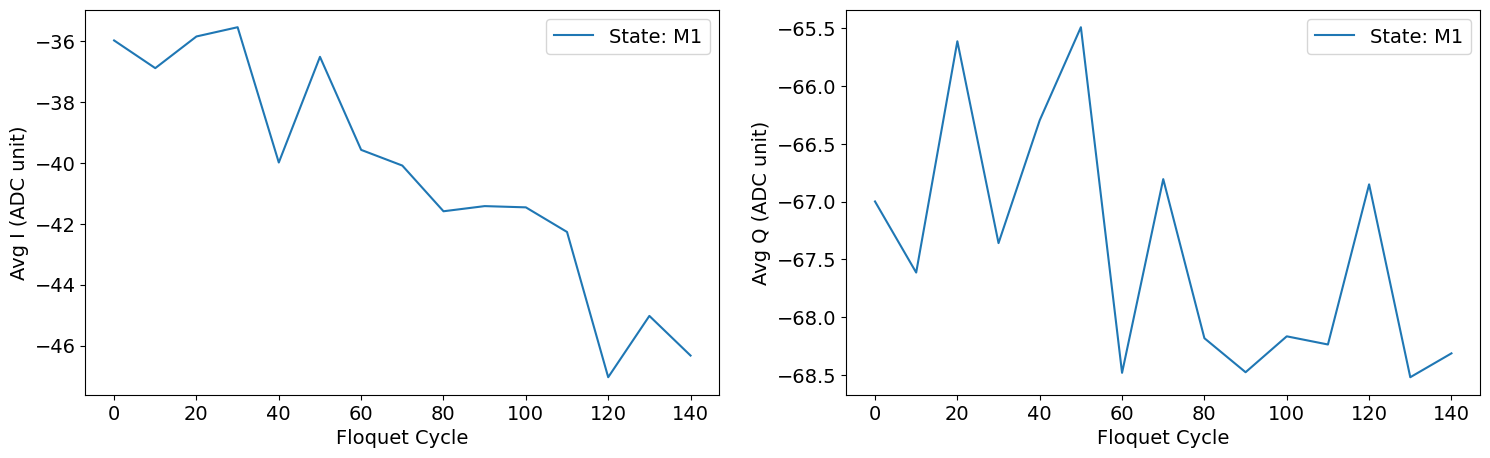

In [88]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

fig, ax = plt.subplots(1, 2, figsize=(18, 5))
scatter = False
combined_data = defaultdict(lambda: {'xpts': [], 'avgi': [], 'avgq': []})

unique_expts = []
for sub_list in scramble_expts:
    for expt in sub_list:
        if expt not in unique_expts:
            unique_expts.append(expt)

for expt in unique_expts:
    state_idx = expt.cfg.expt.ro_stor
    
    combined_data[state_idx]['xpts'].extend(expt.data['xpts'])
    combined_data[state_idx]['avgi'].extend(expt.data['avgi'])
    combined_data[state_idx]['avgq'].extend(expt.data['avgq']) 

for state_idx, data in combined_data.items():
    sort_indices = np.argsort(data['xpts'])
    x_sorted = np.array(data['xpts'])[sort_indices]
    i_sorted = np.array(data['avgi'])[sort_indices]
    q_sorted = np.array(data['avgq'])[sort_indices]

    display_idx = state_idx
    state_prefix = "S"
    if display_idx == 0:
        state_prefix = "M"
        display_idx = 1
        
    label_str = f"State: {state_prefix}{display_idx}"
    if not scatter:
        ax[0].plot(x_sorted, i_sorted, label=label_str)
        ax[1].plot(x_sorted, q_sorted, label=label_str)
    else:
        ax[0].scatter(x_sorted, i_sorted, alpha=0.5, label=label_str)
        ax[1].scatter(x_sorted, q_sorted, alpha=0.5, label=label_str)

ax[0].set_xlabel("Floquet Cycle")
ax[1].set_xlabel("Floquet Cycle")
ax[0].set_ylabel("Avg I (ADC unit)")
ax[1].set_ylabel("Avg Q (ADC unit)")
ax[0].legend()
ax[1].legend()

plt.show()

In [79]:
station.update_all_station_snapshots()

[CONFIG] Reusing existing hardware_config version CFG-HW-20260519-00004
[CONFIG] Reusing existing multiphoton_config version CFG-MP-20260121-00001
[CONFIG] Reusing existing man1_storage_swap version CFG-M1-20260519-00015
[CONFIG] Reusing existing floquet_storage_swap version CFG-FL-20260519-00074
Config snapshots for current station:
  hardware_config: CFG-HW-20260519-00004
  multiphoton_config: CFG-MP-20260121-00001
  man1_storage_swap: CFG-M1-20260519-00015
  floquet_storage_swap: CFG-FL-20260519-00074


{'hardware_config': 'CFG-HW-20260519-00004',
 'multiphoton_config': 'CFG-MP-20260121-00001',
 'man1_storage_swap': 'CFG-M1-20260519-00015',
 'floquet_storage_swap': 'CFG-FL-20260519-00074'}

## Detuning - dependent decay - First Attempt ()

### beam splitting interaction calibration

In [87]:
from tqdm.notebook import tqdm


dmscramble_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.QsimBaseExperiment,
    ExptProgram=meas.SidebandScrambleDarkProgram,
    default_expt_cfg=dm_sideband_scramble_defaults,
    preprocessor=sideband_scramble_preproc,
    postprocessor=None,
    job_client=client,
)

floquet_cycles_list = floquet_cycle_list_gen(0, 120, 120, 10)

meas_stors = [0]
# meas_stors = [0]
swap_stors = [2]
detunings = [0] # None/False/unspecified all default to all zeros
dark_swaps = [2, 3]
scramble_expts = []

rel_phase_list = [0]
# for phase in rel_phase_list:

for meas_stor in tqdm(meas_stors):
    scramble_sub_expts = []
    for floquet_cycles in tqdm(floquet_cycles_list):
        scramble = dmscramble_runner.execute(
            reps=1000,
            init_fock=True,
            init_stor=0,
            ro_stor = meas_stor,
            relax_delay=200,
            active_reset=True,
            pre_relax_delay = 3000,
            man_reset=True, 
            storage_reset = swap_stors, 
            reset_dump_mode = 1,
            dump_reset_iter_num = 1,
            swap_stors=swap_stors,
            update_phases=True,
            detunings=detunings,
            floquet_cycles=floquet_cycles,
            swept_params=['floquet_cycle'],
            custom_prepulse = False,
            custom_postpulse = False,
            debug = True,
            swap_man_dark = False,
            dark_swap_order = dark_swaps,
            second_rel_phase = 180,
            map_to_qubit_ge = True,
            parity_readout = True,
            parity_fast = False,
            phase_second_pulse = 0,
            prepulse = True, #for debugging. Should always be true
            postpulse = True #for debugging. Should always be true
            )
        scramble_sub_expts.append(scramble)
    scramble_expts.append(scramble_sub_expts)
    # scramble.display()

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Job submitted: JOB-20260520-00774 (queue position: 1)

[0.0s] Job JOB-20260520-00774: pending

[2.0s] Job JOB-20260520-00774: running
[WORKER] Loading QsimBaseExperiment from experiments.qsim.qsim_base
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260520-00774_QsimBaseExperiment.h5
[WORKER]   Program: SidebandScrambleDarkProgram from experiments.qsim.t2_cavity_fluxexcursion
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.3mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
  0%|                                                   | 0/12 [00:00<?, ?it/s]overrided man reset is called
resetting stor modes [2]
overrided man reset is called
[{'ch': 1, 'style': 'flat_top', 'freq': 349411128, 'phase': 0, 'gain': 1826, 'length': 105, 'waveform': 'pi_m1si_low'}]
Performing parity readout with parity pulse
  8%|███▌                                       | 1/12 [00:04<00:49,  4.48s/it]overrided man reset is called
resetting stor m

In [88]:
def floquet_cycle_to_time(swap_stors):
    length_per_cycle = 0
    for stor in swap_stors:
        length_per_cycle += station.ds_floquet.get_len(f"M1-S{stor}")
        length_per_cycle += station.soccfg.cycles2us(10)
    return length_per_cycle 

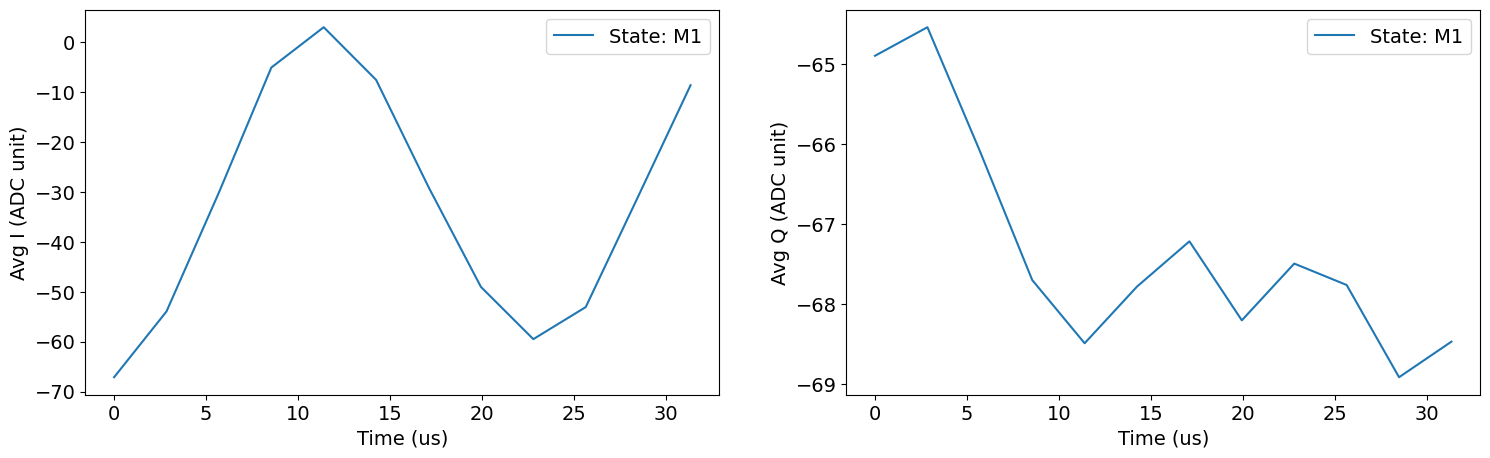

In [89]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

fig, ax = plt.subplots(1, 2, figsize=(18, 5))
scatter = False
combined_data = defaultdict(lambda: {'xpts': [], 'avgi': [], 'avgq': []})

unique_expts = []
for sub_list in scramble_expts:
    for expt in sub_list:
        if expt not in unique_expts:
            unique_expts.append(expt)

for expt in unique_expts:
    state_idx = expt.cfg.expt.ro_stor
    
    combined_data[state_idx]['xpts'].extend(expt.data['xpts'])
    combined_data[state_idx]['avgi'].extend(expt.data['avgi'])
    combined_data[state_idx]['avgq'].extend(expt.data['avgq']) 

for state_idx, data in combined_data.items():
    sort_indices = np.argsort(data['xpts'])
    x_sorted = np.array(data['xpts'])[sort_indices] * floquet_cycle_to_time(swap_stors)
    i_sorted = np.array(data['avgi'])[sort_indices]
    q_sorted = np.array(data['avgq'])[sort_indices]

    display_idx = state_idx
    state_prefix = "S"
    if display_idx == 0:
        state_prefix = "M"
        display_idx = 1
        
    label_str = f"State: {state_prefix}{display_idx}"
    if not scatter:
        ax[0].plot(x_sorted, i_sorted, label=label_str)
        ax[1].plot(x_sorted, q_sorted, label=label_str)
    else:
        ax[0].scatter(x_sorted, i_sorted, alpha=0.5, label=label_str)
        ax[1].scatter(x_sorted, q_sorted, alpha=0.5, label=label_str)

ax[0].set_xlabel("Time (us)")
ax[1].set_xlabel("Time (us)")
ax[0].set_ylabel("Avg I (ADC unit)")
ax[1].set_ylabel("Avg Q (ADC unit)")
ax[0].legend()
ax[1].legend()

plt.show()

In [36]:
from scipy.optimize import curve_fit

def cos_model(t, offset, amp, freq, phase):
    return offset + amp * np.cos(2 * np.pi * freq * t + phase)

def guess_freq_fft(t, y):
    t = np.asarray(t)
    y = np.asarray(y) - np.mean(y)

    tu = np.linspace(t.min(), t.max(), len(t))
    yu = np.interp(tu, t, y)

    dt = tu[1] - tu[0]
    freqs = np.fft.rfftfreq(len(tu), d=dt)
    spec = np.abs(np.fft.rfft(yu))
    spec[0] = 0

    return freqs[np.argmax(spec)]

In [37]:
t_fit_data = x_sorted - x_sorted.min()
i_fit_data = i_sorted

freq_guess = guess_freq_fft(t_fit_data, i_fit_data)
offset_guess = np.mean(i_fit_data)
amp_guess = 0.5 * (np.max(i_fit_data) - np.min(i_fit_data))
phase_guess = 0.0

p0 = [offset_guess, amp_guess, freq_guess, phase_guess]

popt, pcov = curve_fit(
    cos_model,
    t_fit_data,
    i_fit_data,
    p0=p0,
    maxfev=20000
)

offset, amp, freq, phase = popt
freq_err = np.sqrt(np.diag(pcov))[2]

print(f"{label_str}: freq = {freq:.6f} MHz = {freq * 1e3:.3f} kHz")
print(f"{label_str}: freq err ~ {freq_err:.6f} MHz")

State: M1: freq = 0.044378 MHz = 44.378 kHz
State: M1: freq err ~ 0.000160 MHz


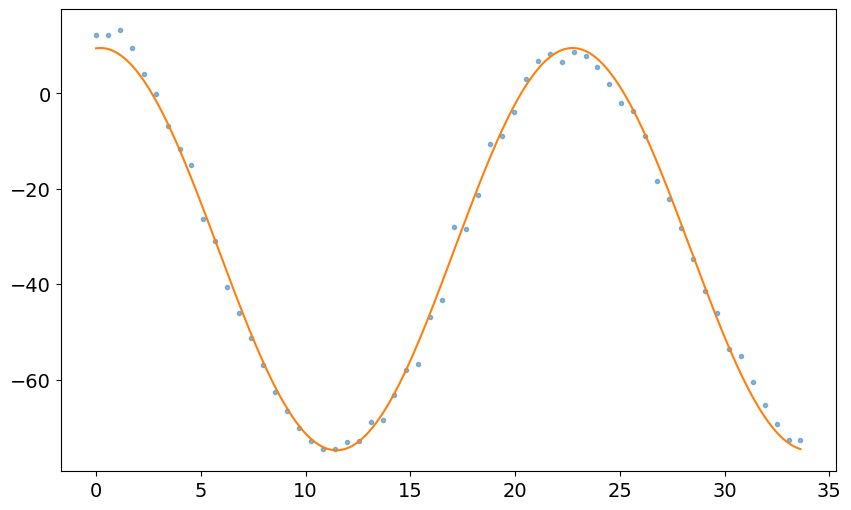

In [39]:
t_dense = np.linspace(t_fit_data.min(), t_fit_data.max(), 1000)
i_dense = cos_model(t_dense, *popt)

plt.plot(x_sorted, i_sorted, ".", alpha=0.5, label=label_str)
plt.plot(t_dense + x_sorted.min(), i_dense, "-", label=f"{label_str} fit, f={freq*1e3:.2f} kHz")

### decay analysis

In [16]:
from tqdm.notebook import tqdm
import numpy as np
from scipy.stats import qmc

sampler = qmc.Sobol(d=4, scramble=True)
m = 4
sobol_floats = sampler.random_base2(m=m)  
random_binarys = np.where(sobol_floats < 0.5, -1, 1) # have no idea what does this do, but confirmed that for m = 4 and d = 4, the result is all possible combinations.


dmscramble_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.QsimBaseExperiment,
    ExptProgram=meas.SidebandScrambleDarkProgram,
    default_expt_cfg=dm_sideband_scramble_defaults,
    preprocessor=sideband_scramble_preproc,
    postprocessor=None,
    job_client=client,
)


g = 11.09e-3 #should be measured above
detuning_list = g * np.logspace(-2, 1, 5)
np.insert(detuning_list, 0, 0)
# detuning_list = [0]

floquet_cycles_list = floquet_cycle_list_gen(0, 300, 100, 5)
meas_stors = [0]
# meas_stors = [0]
swap_stors = [2, 3, 5, 6]
# detunings = [0, 0, 0, 0] # None/False/unspecified all default to all zeros
dark_swaps = [3, 5]
scramble_expts = []

rel_phase_list = [0]
# for phase in rel_phase_list:

for detun in tqdm(detuning_list):
    scramble_sub_expts = []
    for random_binary in tqdm(random_binarys):
        scramble_subsub_expts = []
        detunings = (random_binary * detun).astype(float).tolist()
        for floquet_cycles in floquet_cycles_list:
            scramble = dmscramble_runner.execute(
                reps=100,
                # init_fock=True,
                init_alpha = 2,
                init_stor=3,
                ro_stor = meas_stors[0],
                relax_delay=200,
                active_reset=True,
                pre_relax_delay = 3000,
                man_reset=True, 
                storage_reset = swap_stors, 
                reset_dump_mode = 1,
                dump_reset_iter_num = 1,
                swap_stors=swap_stors,
                update_phases=True,
                detunings=detunings,
                floquet_cycles=floquet_cycles,
                swept_params=['floquet_cycle'],
                custom_prepulse = False,
                custom_postpulse = False,
                debug = False,
                swap_man_dark = True,
                dark_swap_order = dark_swaps,
                second_rel_phase = 180,
                map_to_qubit_ge = True, 
                parity_readout = True,
                parity_fast = False,
                phase_second_pulse = 180,
                prepulse = True, #for debugging. Should always be true
                postpulse = True #for debugging. Should always be trues
                )
            scramble_subsub_expts.append(scramble)
        scramble_sub_expts.append(scramble_subsub_expts)
    scramble_expts.append(scramble_sub_expts)

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

Job submitted: JOB-20260521-00224 (queue position: 1)

[0.0s] Job JOB-20260521-00224: pending

[2.0s] Job JOB-20260521-00224: running
[WORKER] Loading QsimBaseExperiment from experiments.qsim.qsim_base
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260521-00224_QsimBaseExperiment.h5
[WORKER]   Program: SidebandScrambleDarkProgram from experiments.qsim.t2_cavity_fluxexcursion
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.3mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 90%|█████████████████████████████████████▊    | 18/20 [00:15<00:02,  1.01s/it]resetting stor modes [2, 3, 5, 6]

[40.3s] Job JOB-20260521-00224: completed
100%|██████████████████████████████████████████| 20/20 [00:17<00:00,  1.15it/s]
Saving D:\experiments\260511_qsim_darkmode\data\JOB-20260521-00224_QsimBaseExperiment.h5
[WORKER] Saving expt object to: D:\experiments\260511_qsim_darkmode\expt_objs\JOB-20260521-00224_expt.pkl

Job completed! Data: 

RuntimeError: Job JOB-20260521-00250 failed: Job cancelled by user (Ctrl+C)

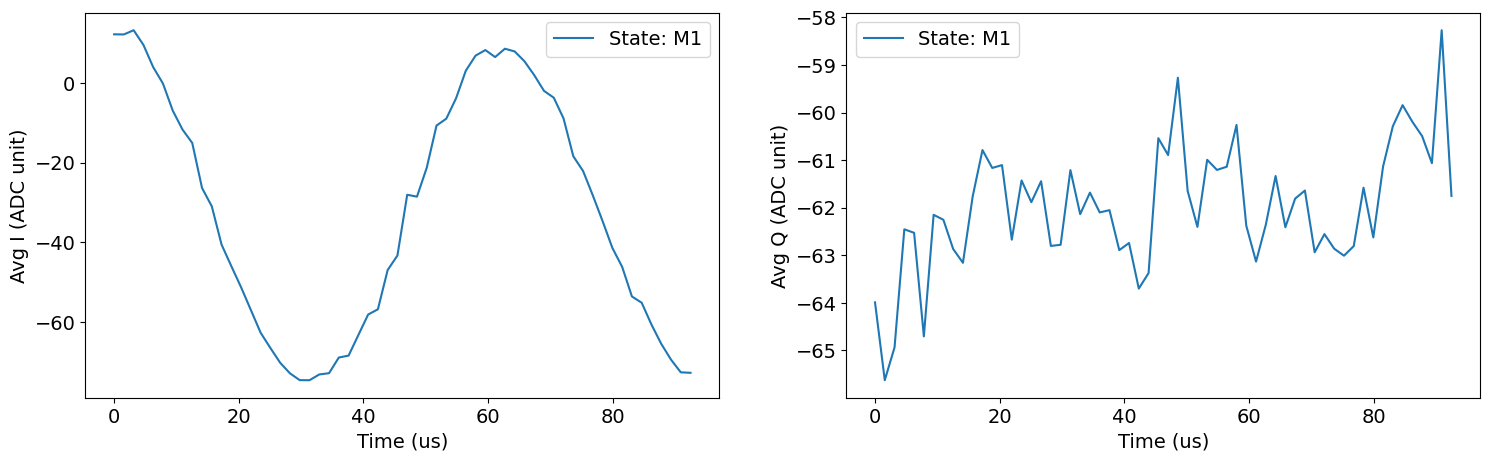

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

fig, ax = plt.subplots(1, 2, figsize=(18, 5))
scatter = False
combined_data = defaultdict(lambda: {'xpts': [], 'avgi': [], 'avgq': []})

unique_expts = []
for subsub_list in scramble_expts:
    for expt in sub_list:
        if expt not in unique_expts:
            unique_expts.append(expt)

for expt in unique_expts:
    state_idx = expt.cfg.expt.ro_stor
    
    combined_data[state_idx]['xpts'].extend(expt.data['xpts'])
    combined_data[state_idx]['avgi'].extend(expt.data['avgi'])
    combined_data[state_idx]['avgq'].extend(expt.data['avgq']) 

for state_idx, data in combined_data.items():
    sort_indices = np.argsort(data['xpts'])
    x_sorted = np.array(data['xpts'])[sort_indices] * floquet_cycle_to_time(swap_stors)
    i_sorted = np.array(data['avgi'])[sort_indices]
    q_sorted = np.array(data['avgq'])[sort_indices]

    display_idx = state_idx
    state_prefix = "S"
    if display_idx == 0:
        state_prefix = "M"
        display_idx = 1
        
    label_str = f"State: {state_prefix}{display_idx}"
    if not scatter:
        ax[0].plot(x_sorted, i_sorted, label=label_str)
        ax[1].plot(x_sorted, q_sorted, label=label_str)
    else:
        ax[0].scatter(x_sorted, i_sorted, alpha=0.5, label=label_str)
        ax[1].scatter(x_sorted, q_sorted, alpha=0.5, label=label_str)

ax[0].set_xlabel("Time (us)")
ax[1].set_xlabel("Time (us)")
ax[0].set_ylabel("Avg I (ADC unit)")
ax[1].set_ylabel("Avg Q (ADC unit)")
ax[0].legend()
ax[1].legend()

plt.show()

## Single shot distribution inv

In [ ]:
# Execute
# =================================
ss_runner = CharacterizationRunner(
    station = station,
    ExptClass = meas.HistogramExperiment,
    default_expt_cfg = singleshot_defaults,
    postprocessor = singleshot_postproc,
    job_client=client,
)

ss = ss_runner.execute(
    check_f=False,
    active_reset=False, # on recalibration of readout, turn off active reset because it will be wrong for selecting when to apply the qubit pulse
    relax_delay=2000,
    # active_reset=True,
    # relax_delay=200,
    priority=1,
)
ss.display(station)

In [ ]:
from tqdm.notebook import tqdm


dmscramble_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.QsimBaseExperiment,
    ExptProgram=meas.SidebandScrambleDarkProgram,
    default_expt_cfg=dm_sideband_scramble_defaults,
    preprocessor=sideband_scramble_preproc,
    postprocessor=None,
    job_client=client,
)

floquet_cycles = [0]

meas_stors = [0]
# meas_stors = [0]
swap_stors = [2, 3]
detunings = [0, 0] # None/False/unspecified all default to all zeros

scramble_expts = []

rel_phase_list = [0]
# for phase in rel_phase_list:

for meas_stor in tqdm(meas_stors):
    scramble = dmscramble_runner.execute(
        reps=5000,
        init_fock=True,
        init_stor=0,
        ro_stor = meas_stor,
        relax_delay=200,
        active_reset=True,
        pre_relax_delay = 1000,
        man_reset=True, 
        storage_reset = [2, 3], 
        reset_dump_mode = 1,
        dump_reset_iter_num = 1,
        swap_stors=swap_stors,
        update_phases=True,
        detunings=detunings,
        floquet_cycles=floquet_cycles,  
        swept_params=['floquet_cycle'],
        custom_prepulse = False,
        custom_postpulse = False,
        debug = False,
        swap_man_dark = True,
        dark_swap_order = [2, 3],
        second_rel_phase = 180,
        map_to_qubit_ge = True,
        prepulse = True, #for debugging. Should always be true
        postpulse = True #for debugging. Should always be true
        )
    scramble_expts.append(scramble)
    # scramble.display()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from experiments.MM_base import MMAveragerProgram

idx_to_plot = 0
subidx = 0

I_threshold = 0.0 

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
ax, ax1 = axes

read_num = 1
if scramble_expts[idx_to_plot].cfg.expt.get('parity_check', False):
    read_num += 1
if scramble_expts[idx_to_plot].cfg.expt.get('active_reset', False):
    params = MMAveragerProgram.get_active_reset_params(scramble_expts[idx_to_plot].cfg)
    read_num += MMAveragerProgram.active_reset_read_num(**params)
_start_idx = read_num-1

idata_g = ss.data['Ig']
qdata_g = ss.data['Qg']
idata_scramble = scramble_expts[idx_to_plot].data['idata'][subidx][_start_idx::read_num]
qdata_scramble = scramble_expts[idx_to_plot].data['qdata'][subidx][_start_idx::read_num]

frac_g = np.mean(idata_g > I_threshold) * 100 
frac_scramble = np.mean(idata_scramble > I_threshold) * 100

ax.scatter(idata_g, qdata_g, alpha=0.1, label='single shot of g')
ax.scatter(idata_scramble, qdata_scramble, alpha=0.2, label='single shot after initialization')

ax1.hist(idata_scramble, bins=100)

ax.axvline(x=I_threshold, color='red', linestyle='--', alpha=0.7, label=f'Threshold ({I_threshold})')
ax1.axvline(x=I_threshold, color='red', linestyle='--', alpha=0.7)

ax.set_title(
    f"Average I: {np.round(np.average(idata_scramble), 2)} | Desired Avg I: {np.round(np.average(idata_g), 2)}\n"
    f"g > threshold: {frac_g:.1f}% | init > threshold: {frac_scramble:.1f}%"
)
ax1.set_title(f"Histogram (init > threshold: {frac_scramble:.1f}%)")

ax.legend()
plt.show()

## Prerelax/Relax delay vs average I

In [ ]:
dmscramble_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.QsimBaseExperiment,
    ExptProgram=meas.SidebandScrambleDarkProgram,
    default_expt_cfg=dm_sideband_scramble_defaults,
    preprocessor=sideband_scramble_preproc,
    postprocessor=None,
    job_client=client,
)

floquet_cycles = [0]

meas_stors = [0]
# meas_stors = [0]
swap_stors = [2, 3]
detunings = [0, 0] # None/False/unspecified all default to all zeros


rel_phase_list = [0]
total_exps = []
pre_relax_delay_list = np.arange(0, 5001, 500)
for pre_relax_delay in pre_relax_delay_list:
    scramble_expts = []
    for meas_stor in meas_stors:
        scramble = dmscramble_runner.execute(
            reps=5000,
            init_fock=True,
            init_stor=1,
            ro_stor = meas_stor,
            relax_delay=200,
            active_reset=True,
            pre_relax_delay = pre_relax_delay,
            man_reset=True, 
            storage_reset = [2, 3], 
            reset_dump_mode = 1,
            dump_reset_iter_num = 1,
            swap_stors=swap_stors,
            update_phases=True,
            detunings=detunings,
            floquet_cycles=floquet_cycles,  
            swept_params=['floquet_cycle'],
            custom_prepulse = False,
            custom_postpulse = False,
            debug = False,
            swap_man_dark = True,
            dark_swap_order = [2, 3],
            second_rel_phase = 180,
            map_to_qubit_ge = True,
            prepulse = True, #for debugging. Should always be true
            postpulse = True #for debugging. Should always be true
            )
        scramble_expts.append(scramble)
    total_exps.append(scramble_expts)
    

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from experiments.MM_base import MMAveragerProgram

idx_to_plot = 0
subidx = 0
I_threshold = 0.0 

idata_g = ss.data['Ig']
qdata_g = ss.data['Qg']

avg = np.round(np.average(idata_g), 2)
avg_list_prerelax = []
frac_list_prerelax = []
frac_g = np.mean(idata_g > I_threshold) * 100 

for scramble_expts in total_exps:
    read_num = 1
    if scramble_expts[idx_to_plot].cfg.expt.get('parity_check', False):
        read_num += 1
    if scramble_expts[idx_to_plot].cfg.expt.get('active_reset', False):
        params = MMAveragerProgram.get_active_reset_params(scramble_expts[idx_to_plot].cfg)
        read_num += MMAveragerProgram.active_reset_read_num(**params)
    _start_idx = read_num-1

    idata_scramble = scramble_expts[idx_to_plot].data['idata'][subidx][_start_idx::read_num]
    qdata_scramble = scramble_expts[idx_to_plot].data['qdata'][subidx][_start_idx::read_num]

    frac_scramble = np.mean(idata_scramble > I_threshold) * 100
    each_avg = np.round(np.average(idata_scramble), 2)
    avg_list_prerelax.append(each_avg)
    frac_list_prerelax.append(frac_scramble)
fig, ax = plt.subplots()
ax.scatter(pre_relax_delay_list, avg_list_prerelax, label = "active reset ON")
# ax.scatter(relax_delay_list, avg_list, label = "active reset OFF")
# ax.axhline(y=avg, color='red', linestyle='--', alpha=0.7, label=f'Mean avg I of g from single shot')
ax.legend()
plt.show()

In [ ]:
dmscramble_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.QsimBaseExperiment,
    ExptProgram=meas.SidebandScrambleDarkProgram,
    default_expt_cfg=dm_sideband_scramble_defaults,
    preprocessor=sideband_scramble_preproc,
    postprocessor=None,
    job_client=client,
)

floquet_cycles = [0]

meas_stors = [0]
# meas_stors = [0]
swap_stors = [2, 3]
detunings = [0, 0] # None/False/unspecified all default to all zeros


rel_phase_list = [0]
total_exps = []
relax_delay_list = np.arange(2001, 8001, 1000)
for relax_delay in relax_delay_list:
    scramble_expts = []
    for meas_stor in meas_stors:
        scramble = dmscramble_runner.execute(
            reps=5000,
            init_fock=True,
            init_stor=0,
            ro_stor = meas_stor,
            relax_delay=relax_delay,
            active_reset=False,
            pre_relax_delay = 0,
            man_reset=True, 
            storage_reset = [2, 3], 
            reset_dump_mode = 1,
            dump_reset_iter_num = 1,
            swap_stors=swap_stors,
            update_phases=True,
            detunings=detunings,
            floquet_cycles=floquet_cycles,  
            swept_params=['floquet_cycle'],
            custom_prepulse = False,
            custom_postpulse = False,
            debug = False,
            swap_man_dark = True,
            dark_swap_order = [2, 3],
            second_rel_phase = 180,
            map_to_qubit_ge = True,
            prepulse = True, #for debugging. Should always be true
            postpulse = True #for debugging. Should always be true
            )
        scramble_expts.append(scramble)
    total_exps.append(scramble_expts)
    

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from experiments.MM_base import MMAveragerProgram

idx_to_plot = 0
subidx = 0
I_threshold = 0.0 

idata_g = ss.data['Ig']
qdata_g = ss.data['Qg']

avg = np.round(np.average(idata_g), 2)
avg_list = []
frac_list = []
frac_g = np.mean(idata_g > I_threshold) * 100 

for scramble_expts in total_exps:
    read_num = 1
    if scramble_expts[idx_to_plot].cfg.expt.get('parity_check', False):
        read_num += 1
    if scramble_expts[idx_to_plot].cfg.expt.get('active_reset', False):
        params = MMAveragerProgram.get_active_reset_params(scramble_expts[idx_to_plot].cfg)
        read_num += MMAveragerProgram.active_reset_read_num(**params)
    _start_idx = read_num-1

    idata_scramble = scramble_expts[idx_to_plot].data['idata'][subidx][_start_idx::read_num]
    qdata_scramble = scramble_expts[idx_to_plot].data['qdata'][subidx][_start_idx::read_num]

    frac_scramble = np.mean(idata_scramble > I_threshold) * 100
    each_avg = np.round(np.average(idata_scramble), 2)
    avg_list.append(each_avg)
    frac_list.append(frac_scramble)
fig, ax = plt.subplots()
ax.scatter(relax_delay_list, avg_list)
# ax.axhline(y=avg, color='red', linestyle='--', alpha=0.7, label=f'Mean g from single shot')
ax.legend()
ax.set_xlabel("relax delay (us)")
ax.set_ylabel("Avg I [ADC unit]")
plt.show()

## Dark Mode T1

In [71]:
dm_T1_defaults = AttrDict(dict(
    expts=1,
    reps=100,
    rounds=1,
    qubits=[0],
    ro_stor=0, # storage mode number that gets read out in the end
    init_fock=True,
    normalize=False,
    post_select_pre_pulse=False,
    active_reset=False,
    man_reset=False, 
    storage_reset=False, 
    prepulse=True,
    postpulse=True,
)) # Shouldn't be modifying this on the fly!
# You can use kwargs in the run function to override these values

def dm_T1_preproc(station, default_expt_cfg, **kwargs):
    assert 'swept_params' in kwargs
    assert len(kwargs['swept_params']) > 0

    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)
    assert 'init_stor' in kwargs
    if not expt_cfg.init_fock:
        assert 'init_alpha' in kwargs
        
    # print(expt_cfg)
    return expt_cfg

dmt1runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.qsim.floquet_dark_mode_readout.DarkT1Experiment,
    ExptProgram=meas.qsim.floquet_dark_mode_readout.DarkT1Program,
    default_expt_cfg=dm_T1_defaults,
    preprocessor=dm_T1_preproc,
    postprocessor=None,
    job_client=client,
)



In [ ]:
np.arange(0, 10, 1)

Job submitted: JOB-20260519-00404 (queue position: 1)

[0.3s] Job JOB-20260519-00404: pending

[2.4s] Job JOB-20260519-00404: running
[WORKER] Loading DarkT1Experiment from experiments.qsim.floquet_dark_mode_readout
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260519-00404_DarkT1Experiment.h5
[WORKER]   Program: DarkT1Program from experiments.qsim.floquet_dark_mode_readout
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.3mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 99%|████████████████████████████████████████▌| 99/100 [03:36<00:03,  3.35s/it]resetting stor modes [3, 5]

[232.7s] Job JOB-20260519-00404: completed
100%|████████████████████████████████████████| 100/100 [03:40<00:00,  2.20s/it]
Saving D:\experiments\260511_qsim_darkmode\data\JOB-20260519-00404_DarkT1Experiment.h5
[WORKER] Saving expt object to: D:\experiments\260511_qsim_darkmode\expt_objs\JOB-20260519-00404_expt.pkl

Job completed! Data: D:\expe

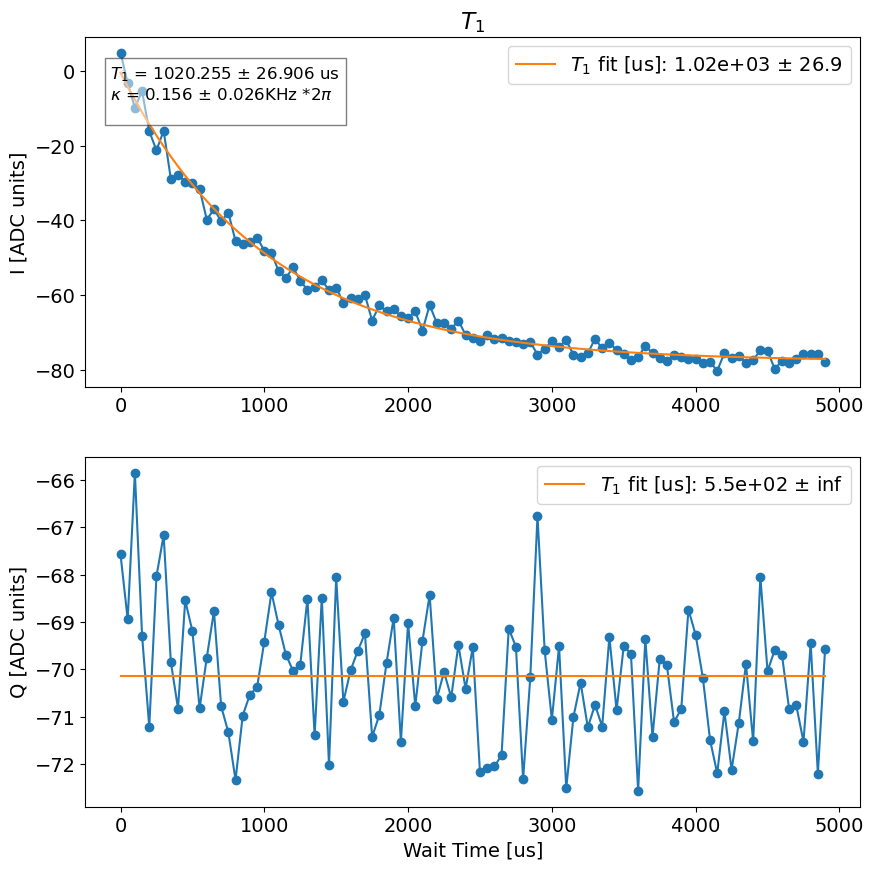

In [78]:

# meas_stors = [0]
swap_stors = [3, 5]
detunings = [0, 0] # None/False/unspecified all default to all zeros

scramble_expts = []

rel_phase_list = [0]
# for phase in rel_phase_list:
wait_lengths = np.arange(0, 5000, 50)

dmt1expt = dmt1runner.execute(
    reps=500,
    init_fock=True,
    init_stor=0,
    ro_stor = 0,
    relax_delay=200,
    active_reset=True,
    pre_relax_delay = 200,
    man_reset=True, 
    storage_reset = swap_stors, 
    reset_dump_mode = 1,
    swap_stors=swap_stors,
    update_phases=True,
    wait_lengths=wait_lengths,  
    swept_params=['wait_length'],
    custom_prepulse = False,
    custom_postpulse = False,
    debug = False,
    swap_man_dark = True,
    dark_swap_order = swap_stors,
    second_rel_phase = 0,
    map_to_qubit_ge = True,
    prepulse = True, #for debugging. Should always be true
    postpulse = True, #for debugging. Should always be true
    track_dark_wait_phase = True,
    dark_wait_phase_rate_MHz = -0.04407440214131276, #-,

    # If the oscillation gets worse or shifts the wrong way, flip the sign.
    # dark_wait_phase_rate_MHz = -0.0175
    dark_wait_phase_offset_deg = 0.0
    )
dmt1expt.display()

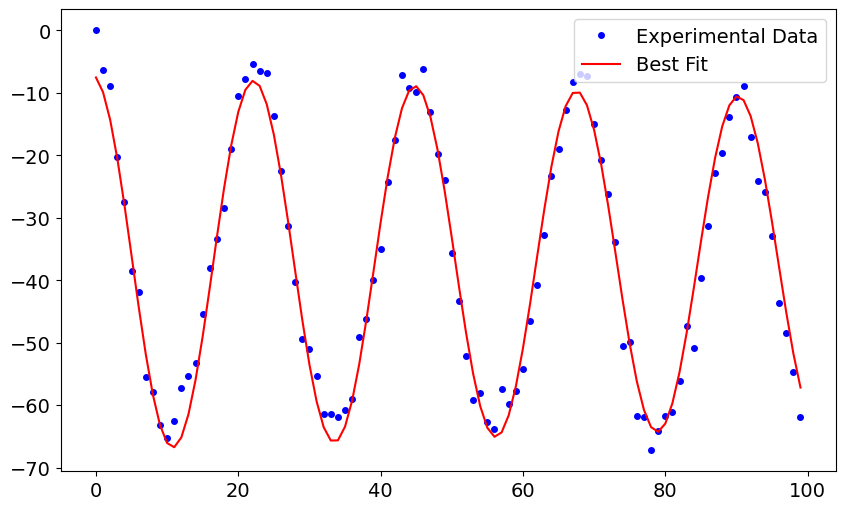

0.04407440214131276

In [76]:
from lmfit import Model

def exp_decay(x, f, phi, A, T1, C):
    return A * np.exp(-x / T1) * np.sin(2*np.pi*f*x+phi) + C

fit = Model(exp_decay)

params = fit.make_params(f=0.0175, phi=0, A=70, T1=100, C=-70)

result = fit.fit(dmt1expt.data['avgi'], params, x=dmt1expt.data['xpts'])

plt.plot(dmt1expt.data['xpts'], dmt1expt.data['avgi'], 'bo', label='Experimental Data', markersize=4)
plt.plot(dmt1expt.data['xpts'], result.best_fit, 'r-', label='Best Fit')       # 최적화된 결과 그래프
plt.legend()
plt.show()

result.values['f']


In [46]:
station.update_all_station_snapshots()

[CONFIG] Reusing existing hardware_config version CFG-HW-20260520-00001
[CONFIG] Reusing existing multiphoton_config version CFG-MP-20260121-00001
[CONFIG] Reusing existing man1_storage_swap version CFG-M1-20260519-00015
[CONFIG] Reusing existing floquet_storage_swap version CFG-FL-20260520-00001
Config snapshots for current station:
  hardware_config: CFG-HW-20260520-00001
  multiphoton_config: CFG-MP-20260121-00001
  man1_storage_swap: CFG-M1-20260519-00015
  floquet_storage_swap: CFG-FL-20260520-00001


{'hardware_config': 'CFG-HW-20260520-00001',
 'multiphoton_config': 'CFG-MP-20260121-00001',
 'man1_storage_swap': 'CFG-M1-20260519-00015',
 'floquet_storage_swap': 'CFG-FL-20260520-00001'}

# Test lines

In [ ]:
station.soccfg.reg2freq(station.soccfg.freq2reg(7600, gen_ch=4), gen_ch=4)

In [ ]:
6881.28-718.72

In [ ]:
station.soccfg.freq2reg(1210.24, gen_ch=4)

In [ ]:
station.soccfg.reg2freq(station.soccfg.freq2reg(7600, gen_ch=1), gen_ch=1)

In [ ]:
station.soccfg.reg2freq(station.soccfg.freq2reg(7000, gen_ch=1), gen_ch=1)+6389.76

In [21]:
station.hardware_cfg.hw.soc.dacs.flux_high.ch

[1]

In [ ]:
station.hardware

In [19]:
from qick import AveragerProgram

In [31]:
class LoopbackProgram(AveragerProgram):
    def initialize(self):
        cfg=self.cfg 
        res_ch = cfg["res_ch"]

        # set the nyquist zone
        self.declare_gen(ch=cfg["res_ch"], nqz=cfg["nyquist_zone"])
        
        # configure the readout lengths and downconversion frequencies (ensuring it is an available DAC frequency)
        for ch in cfg["ro_chs"]:
            self.declare_readout(ch=ch, length=self.cfg["readout_length"],
                                 freq=self.cfg["pulse_freq"], gen_ch=cfg["res_ch"])

        # convert frequency to DAC frequency (ensuring it is an available ADC frequency)
        freq = self.freq2reg(cfg["pulse_freq"],gen_ch=res_ch) #, ro_ch=cfg["ro_chs"][0])
        phase = self.deg2reg(cfg["res_phase"], gen_ch=res_ch)
        gain = cfg["pulse_gain"]
        
        # self.default_pulse_registers(ch=res_ch, freq=freq, phase=phase, gain=gain)

        # self.set_pulse_registers(ch=res_ch, style=style, length=cfg["length"],freq=freq, phase=phase, gain=gain)
        self.synci(200)  # give processor some time to configure pulses
    
    def body(self):
        # fire the pulse
        # trigger all declared ADCs
        # pulse PMOD0_0 for a scope trigger
        # pause the tProc until readout is done
        # increment the time counter to give some time before the next measurement
        # (the syncdelay also lets the tProc get back ahead of the clock)
        cfg=self.cfg 
        res_ch = cfg["res_ch"]
        freq = self.freq2reg(cfg["pulse_freq"],gen_ch=res_ch)#, ro_ch=cfg["ro_chs"][0])
        phase = self.deg2reg(cfg["res_phase"], gen_ch=res_ch)
        gain = cfg["pulse_gain"]
        self.setup_and_pulse(ch = self.cfg["res_ch"],
                             style="const", 
                             length=cfg["length"],
                             freq=freq, 
                             phase=phase, 
                             gain=gain)
                             #,mode = "periodic")
        self.sync_all(10)
        self.measure(pulse_ch=self.cfg["res_ch"], 
                     adcs=self.ro_chs,
                     pins=[0], 
                     adc_trig_offset=self.cfg["adc_trig_offset"],
                     wait=True,
                     syncdelay=self.us2cycles(self.cfg["relax_delay"]))


class StoppingProgram(LoopbackProgram):
    def body(self):
        self.set_pulse_registers(ch=self.cfg["res_ch"], style="const", length=16, mode = "oneshot")
        self.pulse(ch = self.cfg["res_ch"])

In [34]:
config={"res_ch":1, # --Fixed
        "ro_chs":[0], # --Fixed
        "reps":100, # --Fixed
        "relax_delay": 0,# --us
        "res_phase":0, # --degrees
        "pulse_style": "const", # --Fixed
        
        "length":1000, # [Clock ticks]
        "readout_length":10, # [Clock ticks]

        "pulse_gain":0, # [DAC units]
        "pulse_freq": 2250, # [MHz]
        "nyquist_zone": 1,
        
        "adc_trig_offset": 100, # [Clock ticks]
        "soft_avgs":50
       }

###################
# Try it yourself !
###################
prog =LoopbackProgram(station.soccfg, config)
iq_list = prog.acquire(station.im["Qick101"],
                       progress=True,
                       threshold=None,
                       load_pulses=True)
# prog.run_rounds(im["Qick101"], 
#                         progress=True)
# iq_list = prog.acquire_decimated(soc, progress=True)

  0%|          | 0/50 [00:00<?, ?it/s]

In [27]:
station.ds_floquet.update_gain('M1-S1', 30000)

In [24]:
station.ds_floquet.df

,stor_name,pi_frac,freq (MHz),gain (DAC units),len (mus),ramp_sigma (mus),phase_from_M1-S1 (deg),phase_from_M1-S2 (deg),phase_from_M1-S3 (deg),phase_from_M1-S4 (deg),phase_from_M1-S5 (deg),phase_from_M1-S6 (deg),phase_from_M1-S7 (deg),last_update
0,M1-S1,40,348.599089,10000,0.087217,0.005008,0.000000,0.386219,-0.640180,1.594181,2.476523,-9.388229,-12.480106,2026-05-21 15:33:45.588627
1,M1-S2,40,519.830093,1826,0.261675,0.005008,-0.069409,0.000000,-0.711683,-7.210305,2.135775,2.144909,-6.049181,2026-05-19 13:52:09.656497
2,M1-S3,40,695.944831,1889,0.114046,0.005008,0.516136,1.803723,0.000000,-1.489490,3.384572,3.105996,-2.604314,2026-05-19 14:03:26.230815
3,M1-S4,40,872.274104,10000,0.100000,0.005008,-0.850102,4.908633,1.204000,0.000000,2.838397,0.000000,0.000000,2026-05-19 09:30:45.581396
4,M1-S5,40,1051.952649,1808,0.173495,0.005008,-1.628328,-3.409704,-2.592411,-3.018993,0.000000,-0.076422,0.000000,2026-05-19 14:14:57.471915
5,M1-S6,40,1243.748699,30000,0.141469,0.005008,-1.707704,-3.563466,-2.522659,0.000000,-0.263436,0.000000,-0.994739,2026-05-21 16:23:43.698089
6,M1-S7,1,1422.577240,15221,0.983315,0.005008,17.044524,4.529378,1.914683,0.000000,0.000000,1.045383,0.000000,2026-05-19 09:30:07.593623


Starting experiment for storage modes: 1 from 6
{'expts': 1, 'reps': 5000, 'rounds': 1, 'qubits': [0], 'f0g1_cavity': 1, 'init_stor': 0, 'ro_stor': 0, 'advance_phases': [-40.0, -38.4, -36.8, -35.2, -33.6, -32.0, -30.4, -28.799999999999997, -27.2, -25.6, -24.0, -22.4, -20.799999999999997, -19.2, -17.599999999999998, -16.0, -14.399999999999999, -12.799999999999997, -11.2, -9.599999999999998, -8.0, -6.399999999999999, -4.799999999999997, -3.1999999999999957, -1.5999999999999943, 0.0, 1.6000000000000014, 3.200000000000003, 4.800000000000004, 6.400000000000006, 8.0, 9.600000000000001, 11.200000000000003, 12.800000000000004, 14.400000000000006, 16.0, 17.6, 19.200000000000003, 20.800000000000004, 22.400000000000006, 24.0, 25.60000000000001, 27.200000000000003, 28.799999999999997, 30.400000000000006, 32.0, 33.60000000000001, 35.2, 36.80000000000001, 38.400000000000006, 40.0], 'n_pulses': [30], 'swept_params': ['n_pulse', 'advance_phase'], 'normalize': False, 'active_reset': False, 'man_reset':

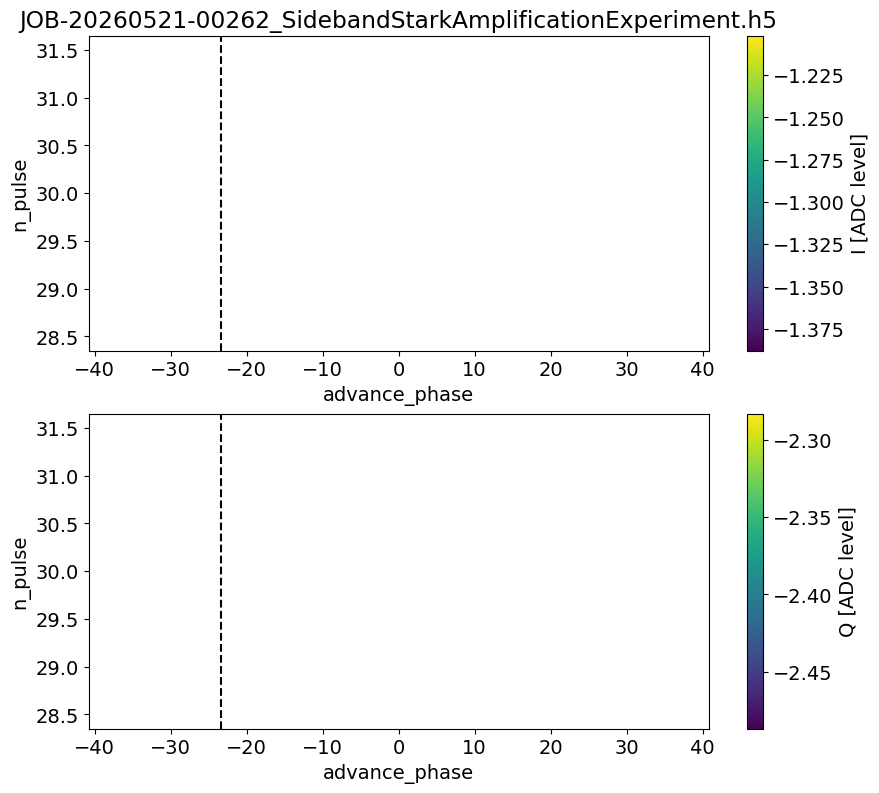

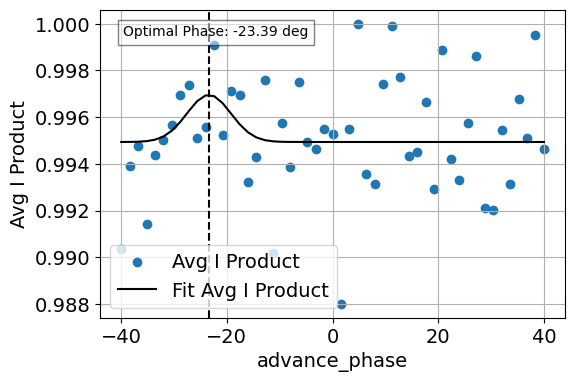

Opt phase on M1-S1 from M1-S6 : -23.388447878264735
[CONFIG] Created new floquet_storage_swap version CFG-FL-20260521-00013


In [33]:
stor_modes_to = [1] #list(range(1,8))
stor_modes_from = [6]
for iA, init_storA in enumerate(stor_modes_to): #range(1,8):
    for iB, init_storB in enumerate(stor_modes_from): #range(1,8):
        if init_storA == init_storB:
            continue
        print("Starting experiment for storage modes:", init_storA, "from", init_storB)

        qbe = sideband_stark_error_amp_runner.execute(
            stor_A=init_storA,
            stor_B=init_storB,
            relax_delay=0,
            reps=5000,
            include_10cycles_buffer = True,
            advance_phases=np.linspace(-40, 40, 51).tolist(),
            n_pulses=[30],
            coupler_current = 0.0
        )
        phase_expts[init_storA - 1][init_storB - 1] = qbe

In [ ]:
dmscramble_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.QsimBaseExperiment,
    ExptProgram=meas.SidebandScrambleDarkProgram,
    default_expt_cfg=dm_sideband_scramble_defaults,
    preprocessor=sideband_scramble_preproc,
    postprocessor=None,
    job_client=client,
)

floquet_cycles = np.arange(0, 1001, step=100)

meas_stors = [0]
# meas_stors = [0]
swap_stors = [2]
detunings = [0, 0] # None/False/unspecified all default to all zeros

scramble_expts = []

rel_phase_list = [0]
# for phase in rel_phase_list:

for meas_stor in meas_stors:
    scramble = dmscramble_runner.execute(
        reps=1000,
        init_fock=True,
        init_stor=0,
        ro_stor = meas_stor,
        relax_delay=0,
        active_reset=False,
        pre_relax_delay = 500,
        man_reset=True, 
        storage_reset = [2, 3], 
        reset_dump_mode = 1,
        dump_reset_iter_num = 1,
        swap_stors=swap_stors,
        update_phases=True,
        detunings=detunings,
        floquet_cycles=floquet_cycles,  
        swept_params=['floquet_cycle'],
        custom_prepulse = False,
        custom_postpulse = False,
        debug = False,
        swap_man_dark = True,
        dark_swap_order = [2, 3],
        second_rel_phase = 180,
        map_to_qubit_ge = True,
        prepulse = False, #for debugging. Should always be true
        postpulse = False
        coupler_current = 0#or debugging. Should always be true
        )
    scramble_expts.append(scramble)
    # scramble.display()

Job submitted: JOB-20260521-00261 (queue position: 1)

[0.0s] Job JOB-20260521-00261: pending

[2.0s] Job JOB-20260521-00261: running
[WORKER] Loading QsimBaseExperiment from experiments.qsim.qsim_base
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260521-00261_QsimBaseExperiment.h5
[WORKER]   Program: SidebandScrambleDarkProgram from experiments.qsim.t2_cavity_fluxexcursion
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.3mA according to hardware_cfg yaml...

[20.2s] Job JOB-20260521-00261: failed
[WORKER] Done setting coupler current
  0%|                                                   | 0/11 [00:00<?, ?it/s]

Job failed: AssertionError: length of detunings doesn't match that of swap_stors
Traceback (most recent call last):
  File "D:\python\multimode_expts\job_server\worker.py", line 366, in _execute_job
    data_file_path, expt_pickle_path = self._run_experiment(ExptClass, expt_config, job)
                                       ^^^^^

RuntimeError: Job JOB-20260521-00261 failed: AssertionError: length of detunings doesn't match that of swap_stors
Traceback (most recent call last):
  File "D:\python\multimode_expts\job_server\worker.py", line 366, in _execute_job
    data_file_path, expt_pickle_path = self._run_experiment(ExptClass, expt_config, job)
                                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\python\multimode_expts\job_server\worker.py", line 552, in _run_experiment
    expt.go(
  File "D:\python\multimode_expts\slab\experiment.py", line 166, in go
    data=self.acquire(progress)
         ^^^^^^^^^^^^^^^^^^^^^^
  File "D:\python\multimode_expts\experiments\qsim\qsim_base.py", line 373, in acquire
    self.prog = self.ProgramClass(soccfg=self.soccfg, cfg=self.cfg)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\python\multimode_expts\experiments\qsim\qsim_base.py", line 32, in __init__
    super().__init__(soccfg, cfg)
  File "D:\p